
###    This code is the practical work for applying the Walder-Hallet (1985) rock fracture model to the experimental data obtained by Murton et. al. (unpublished).


In [2]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import re
import math
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from bisect import bisect_left

import warnings
warnings.filterwarnings('ignore')

In [3]:
def sheet_to_csv(excel_path):
    excel = pd.ExcelFile(excel_path)
    filenames = []
    for sheet_name in excel.sheet_names:
        df = excel.parse(sheet_name)
        csv_filename = f'{sheet_name}.csv'
        df.to_csv(csv_filename, index=False)
        print(f'Saved: {csv_filename}')
        filenames.append(csv_filename)
    return filenames

In [4]:
def read_csv(file_path):
    df = pd.read_csv(file_path, header = 1, low_memory = False)
    return df

In [5]:
caisson_list = sheet_to_csv('Yr2Caissoncycles_1-24_Python_clean.xlsx')
chambreb_list = sheet_to_csv('Yr2Chambrebcycles_1-30_Python_clean.xlsx')

Saved: Cycles_B.csv
Saved: Hdat_B1.csv
Saved: Hdat_B2.csv
Saved: Hdat_B3.csv
Saved: Hdat_B4.csv
Saved: LVDTdat_B.csv
Saved: PWPTdat_B.csv
Saved: Heavedat_B.csv
Saved: Pdat_B.csv
Saved: Tdat_B1.csv
Saved: Tdat_B2.csv
Saved: Tdat_B3.csv
Saved: Tdat_B4.csv
Saved: Wdat_B.csv
Saved: Wdat_mean_B.csv
Saved: ALdat_B.csv
Saved: Cycles_U.csv
Saved: Hdat_U1.csv
Saved: Hdat_U2.csv
Saved: Hdat_U3.csv
Saved: Hdat_U4.csv
Saved: Hdat_U5.csv
Saved: Tdat_U1.csv
Saved: Tdat_U2.csv
Saved: Tdat_U3.csv
Saved: Tdat_U4.csv
Saved: Tdat_U5.csv
Saved: LVDTdat_U.csv
Saved: PWPTdat_U.csv
Saved: Heavedat_U.csv
Saved: Pdat_U.csv
Saved: MFdat_U.csv
Saved: Wdat_U.csv
Saved: Wdat_mean_U.csv


In [6]:
# create data frame of all data frames
caisson_df={}
chambreb_df={}
for file in caisson_list:
    caisson_df[file[:-4]] = read_csv(file)
    print(f'File read: {file}')
for file in chambreb_list:
    chambreb_df[file[:-4]] = read_csv(file)
    print(f'File read: {file}')
print('DONE!')

File read: Cycles_B.csv
File read: Hdat_B1.csv
File read: Hdat_B2.csv
File read: Hdat_B3.csv
File read: Hdat_B4.csv
File read: LVDTdat_B.csv
File read: PWPTdat_B.csv
File read: Heavedat_B.csv
File read: Pdat_B.csv
File read: Tdat_B1.csv
File read: Tdat_B2.csv
File read: Tdat_B3.csv
File read: Tdat_B4.csv
File read: Wdat_B.csv
File read: Wdat_mean_B.csv
File read: ALdat_B.csv
File read: Cycles_U.csv
File read: Hdat_U1.csv
File read: Hdat_U2.csv
File read: Hdat_U3.csv
File read: Hdat_U4.csv
File read: Hdat_U5.csv
File read: Tdat_U1.csv
File read: Tdat_U2.csv
File read: Tdat_U3.csv
File read: Tdat_U4.csv
File read: Tdat_U5.csv
File read: LVDTdat_U.csv
File read: PWPTdat_U.csv
File read: Heavedat_U.csv
File read: Pdat_U.csv
File read: MFdat_U.csv
File read: Wdat_U.csv
File read: Wdat_mean_U.csv
DONE!


In [7]:
for df in chambreb_df:
    print('Data frame: ',df)
    chambreb_df[df].info()
    print()
    print('-------------------------------------------------------------------------------------------')
    print()

Data frame:  Cycles_U
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cycle                 60 non-null     object 
 1   Start date            60 non-null     object 
 2   Start hour            60 non-null     object 
 3   Start day             60 non-null     float64
 4   Finish date           60 non-null     object 
 5   Finish hour           60 non-null     object 
 6   Finish day            60 non-null     float64
 7   Length (days)         60 non-null     float64
 8   period mean air temp  60 non-null     float64
 9   SD (oC)               60 non-null     float64
dtypes: float64(5), object(5)
memory usage: 4.8+ KB

-------------------------------------------------------------------------------------------

Data frame:  Hdat_U1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 12 col

In [8]:
for df in caisson_df:
    print('Data frame: ',df)
    caisson_df[df].info()
    print()
    print('-------------------------------------------------------------------------------------------')
    print()

Data frame:  Cycles_B
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cycle                 48 non-null     object 
 1   Start date            48 non-null     object 
 2   Start hour            48 non-null     object 
 3   Start day             48 non-null     float64
 4   Finish date           48 non-null     object 
 5   Finish hour           48 non-null     object 
 6   Finish day            48 non-null     float64
 7   Length (days)         48 non-null     float64
 8   period mean air temp  48 non-null     float64
 9   SD (oC)               48 non-null     float64
dtypes: float64(5), object(5)
memory usage: 3.9+ KB

-------------------------------------------------------------------------------------------

Data frame:  Hdat_B1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 12 col

In [9]:
# clean B pressure and temp data

T_B_rename_map =  {'100 mm temperature': 'T_100mm', '150 mm temperature': 'T_150mm', '200 mm temperature': 'T_200mm', \
                 '250 mm temperature': 'T_250mm', '300 mm temperature': 'T_300mm', '350 mm temperature': 'T_350mm', \
                 '400 mm temperature': 'T_400mm', '450 mm temperature': 'T_450mm', '50 mm temperature': 'T_050mm', \
                 'surface temperature': 'T_000mm', 'Air temperature': 'air_temp'}
B1_P_rename_map =  {'P_B1_100mm': 'P_100mm', 'P_B1_150mm': 'P_150mm', 'P_B1_200mm': 'P_200mm'}
B2_P_rename_map =  {'P_B2_100mm': 'P_100mm', 'P_B2_150mm': 'P_150mm', 'P_B2_200mm': 'P_200mm'}
B3_P_rename_map =  {'P_B3_100mm': 'P_100mm', 'P_B3_150mm': 'P_150mm', 'P_B3_200mm': 'P_200mm'}
B4_P_rename_map =  {'P_B4_100mm': 'P_100mm', 'P_B4_150mm': 'P_150mm', 'P_B4_200mm': 'P_200mm'}

# drop columns with 'smooth' in them
for key in caisson_df:
    if key.startswith('Tdat'):
        word = 'smooth'
        cols_to_drop = [c for c in caisson_df[key].columns if word.lower() in c.lower()]
        caisson_df[key].drop(columns=cols_to_drop, inplace=True)
        caisson_df[key].reset_index(drop=True, inplace=True)
    elif key == 'Pdat_B':
        word = 'smooth'
        cols_to_drop = [c for c in caisson_df[key].columns if word.lower() in c.lower()]
        caisson_df[key].drop(columns=cols_to_drop, inplace=True)
        caisson_df[key].reset_index(drop=True, inplace=True)

In [10]:
# clean U pressure and temp data

T_U_rename_map =  {'100 mm': 'T_100mm', '150 mm': 'T_150mm', '200 mm': 'T_200mm', \
                 '250 mm': 'T_250mm', '300 mm': 'T_300mm', '350 mm': 'T_350mm', \
                 '400 mm': 'T_400mm', '450 mm': 'T_450mm', '50 mm': 'T_050mm', \
                 'surface': 'T_000mm', 'Air': 'air_temp'}
U1_P_rename_map =  {'P_U1_100mm': 'P_100mm', 'P_U1_150mm': 'P_150mm', 'P_U1_200mm': 'P_200mm', 'P_U1_250mm': 'P_250mm'}
U2_P_rename_map =  {'P_U2_100mm': 'P_100mm', 'P_U2_150mm': 'P_150mm', 'P_U2_200mm': 'P_200mm', 'P_U2_250mm': 'P_250mm'}
U3_P_rename_map =  {'P_U3_100mm': 'P_100mm', 'P_U3_150mm': 'P_150mm', 'P_U3_200mm': 'P_200mm', 'P_U3_250mm': 'P_250mm'}
U4_P_rename_map =  {'P_U4_100mm': 'P_100mm', 'P_U4_150mm': 'P_150mm', 'P_U4_200mm': 'P_200mm', 'P_U4_250mm': 'P_250mm'}
U5_P_rename_map =  {'P_U5_100mm': 'P_100mm', 'P_U5_150mm': 'P_150mm', 'P_U5_200mm': 'P_200mm', 'P_U5_250mm': 'P_250mm'}

# drop columns with 'smooth' in them
for key in chambreb_df:
    if key.startswith('Tdat'):
        word = 'smooth'
        cols_to_drop = [c for c in chambreb_df[key].columns if word.lower() in c.lower()]
        chambreb_df[key].drop(columns=cols_to_drop, inplace=True)
        chambreb_df[key].reset_index(drop=True, inplace=True)
    elif key == 'Pdat_U':
        word = 'smooth'
        cols_to_drop = [c for c in chambreb_df[key].columns if word.lower() in c.lower()]
        chambreb_df[key].drop(columns=cols_to_drop, inplace=True)
        chambreb_df[key].reset_index(drop=True, inplace=True)

In [11]:
# rename B columns
T_B1 = caisson_df['Tdat_B1'].rename(columns=T_B_rename_map)
T_B2 = caisson_df['Tdat_B2'].rename(columns=T_B_rename_map)
T_B3 = caisson_df['Tdat_B3'].rename(columns=T_B_rename_map)
T_B4 = caisson_df['Tdat_B4'].rename(columns=T_B_rename_map)

P_B1 = caisson_df['Pdat_B'][[col for col in caisson_df['Pdat_B'].columns if not any(k in col for k in ['B2', 'B3', 'B4'])]] \
        .rename(columns=B1_P_rename_map)
P_B2 = caisson_df['Pdat_B'][[col for col in caisson_df['Pdat_B'].columns if not any(k in col for k in ['B1', 'B3', 'B4'])]] \
        .rename(columns=B2_P_rename_map)
P_B3 = caisson_df['Pdat_B'][[col for col in caisson_df['Pdat_B'].columns if not any(k in col for k in ['B1', 'B2', 'B4'])]] \
        .rename(columns=B3_P_rename_map)
P_B4 = caisson_df['Pdat_B'][[col for col in caisson_df['Pdat_B'].columns if not any(k in col for k in ['B1', 'B2', 'B3'])]] \
        .rename(columns=B4_P_rename_map)



In [12]:
# rename U columns
T_U1 = chambreb_df['Tdat_U1'].rename(columns=T_U_rename_map)
T_U2 = chambreb_df['Tdat_U2'].rename(columns=T_U_rename_map)
T_U3 = chambreb_df['Tdat_U3'].rename(columns=T_U_rename_map)
T_U4 = chambreb_df['Tdat_U4'].rename(columns=T_U_rename_map)
T_U5 = chambreb_df['Tdat_U5'].rename(columns=T_U_rename_map)

P_U1 = chambreb_df['Pdat_U'][[col for col in chambreb_df['Pdat_U'].columns if not any(k in col for k in ['U2', 'U3', 'U4', 'U5'])]] \
        .rename(columns=B1_P_rename_map)
P_U2 = chambreb_df['Pdat_U'][[col for col in chambreb_df['Pdat_U'].columns if not any(k in col for k in ['U1', 'U3', 'U4', 'U5'])]] \
        .rename(columns=B2_P_rename_map)
P_U3 = chambreb_df['Pdat_U'][[col for col in chambreb_df['Pdat_U'].columns if not any(k in col for k in ['U2', 'U1', 'U4', 'U5'])]] \
        .rename(columns=B3_P_rename_map)
P_U4 = chambreb_df['Pdat_U'][[col for col in chambreb_df['Pdat_U'].columns if not any(k in col for k in ['U2', 'U3', 'U1', 'U5'])]] \
        .rename(columns=B4_P_rename_map)
P_U5 = chambreb_df['Pdat_U'][[col for col in chambreb_df['Pdat_U'].columns if not any(k in col for k in ['U2', 'U3', 'U4', 'U1'])]] \
        .rename(columns=B4_P_rename_map)


In [13]:
# normalise time and merge datasets for B
for label, T, P in [('B1', T_B1.copy(), P_B1.copy()),
                    ('B2', T_B2.copy(), P_B2.copy()),
                    ('B3', T_B3.copy(), P_B3.copy()),
                    ('B4', T_B4.copy(), P_B4.copy()) ]:
    # round days since cycle 1 to 2 decimals
    T['t_d'] = T['Days_since_cycle1'].round(4)
    P['t_d'] = P['Days_since_cycle1'].round(4)
    
    # choose the columns i need
    T_cols = ['t_d'] + [c for c in T.columns if c.startswith('T_')]
    P_cols = ['t_d'] + [c for c in P.columns if c.startswith('P_')]

    #eliminate duplicate measurements
    T_df = T[T_cols].groupby('t_d', as_index=False).mean()
    P_df = P[P_cols].groupby('t_d', as_index=False).mean()

    T_df = T_df.sort_values('t_d')
    P_df = P_df.sort_values('t_d')

    # add a column to signify when two measurements match
    P_df['match'] = 1

    # calculate merged datafram
    out = pd.merge_asof(T_df, P_df, on='t_d', direction='nearest', tolerance=1/48)

    # assign dataframe
    if label == 'B1': B1dat = out
    elif label == 'B2': B2dat = out
    elif label == 'B3': B3dat = out
    elif label == 'B4': B4dat = out

In [14]:
# normalise time and merge datasets for U
for label, T, P in [('U1', T_U1.copy(), P_U1.copy()),
                    ('U2', T_U2.copy(), P_U2.copy()),
                    ('U3', T_U3.copy(), P_U3.copy()),
                    ('U4', T_U4.copy(), P_U4.copy()),
                    ('U5', T_U5.copy(), P_U5.copy())]:
    # round days since cycle 1 to 2 decimals
    T['t_d'] = T['Days_since_cycle1'].round(4)
    P['t_d'] = P['Days_since_cycle1'].round(4)
    
    # choose the columns i need
    T_cols = ['t_d'] + [c for c in T.columns if c.startswith('T_')]
    P_cols = ['t_d'] + [c for c in P.columns if c.startswith('P_')]

    #eliminate duplicate measurements
    T_df = T[T_cols].groupby('t_d', as_index=False).mean()
    P_df = P[P_cols].groupby('t_d', as_index=False).mean()

    T_df = T_df.sort_values('t_d')
    P_df = P_df.sort_values('t_d')

    # add a column to signify when two measurements match
    P_df['match'] = 1

    # calculate merged datafram
    out = pd.merge_asof(T_df, P_df, on='t_d', direction='nearest', tolerance=1/48)

    # assign dataframe
    if label == 'U1': U1dat = out
    elif label == 'U2': U2dat = out
    elif label == 'U3': U3dat = out
    elif label == 'U4': U4dat = out
    elif label == 'U5': U5dat = out

In [15]:
# check nans
for name, data in [('B1dat',B1dat), ('B2dat',B2dat), ('B3dat',B3dat), ('B4dat',B4dat), \
                   ('U1dat',U1dat), ('U2dat',U2dat), ('U3dat',U3dat), ('U4dat',U4dat), ('U5dat',U5dat)]:
    nan_indices = data.index[data.isna().any(axis=1)]
    print(name)
    print(f'amount of non matched rows: {len( data[data['match'].isnull()])}')
    print(f'the number of columns to be removed due to having NaNs is :{len(nan_indices)}')
    print(f'this corresponds to {100*(len(nan_indices)/len(data)):.4f}% of the total {len(data)} data')
    print()


B1dat
amount of non matched rows: 237
the number of columns to be removed due to having NaNs is :268
this corresponds to 2.9115% of the total 9205 data

B2dat
amount of non matched rows: 237
the number of columns to be removed due to having NaNs is :272
this corresponds to 2.9549% of the total 9205 data

B3dat
amount of non matched rows: 237
the number of columns to be removed due to having NaNs is :268
this corresponds to 2.9115% of the total 9205 data

B4dat
amount of non matched rows: 237
the number of columns to be removed due to having NaNs is :273
this corresponds to 2.9658% of the total 9205 data

U1dat
amount of non matched rows: 60
the number of columns to be removed due to having NaNs is :75
this corresponds to 0.7974% of the total 9406 data

U2dat
amount of non matched rows: 60
the number of columns to be removed due to having NaNs is :71
this corresponds to 0.7548% of the total 9406 data

U3dat
amount of non matched rows: 60
the number of columns to be removed due to having

In [16]:
# drop rows of non matched measurements and recheck
for name, data in [('B1dat',B1dat.copy()), ('B2dat',B2dat.copy()), ('B3dat',B3dat.copy()), ('B4dat',B4dat.copy()), \
                   ('U1dat',U1dat.copy()), ('U2dat',U2dat.copy()), ('U3dat',U3dat.copy()), ('U4dat',U4dat.copy()), ('U5dat',U5dat.copy())]:
    data = data[data['match'].notna()].drop(columns=['match'])
    nan_indices = data.index[data.isna().any(axis=1)]
    print(name)
    print(f'the number of columns to be removed due to having NaNs is :{len(nan_indices)}')
    print(f'this corresponds to {100*(len(nan_indices)/len(data)):.4f}% of the total {len(data)} data')
    print()

B1dat
the number of columns to be removed due to having NaNs is :31
this corresponds to 0.3457% of the total 8968 data

B2dat
the number of columns to be removed due to having NaNs is :35
this corresponds to 0.3903% of the total 8968 data

B3dat
the number of columns to be removed due to having NaNs is :31
this corresponds to 0.3457% of the total 8968 data

B4dat
the number of columns to be removed due to having NaNs is :36
this corresponds to 0.4014% of the total 8968 data

U1dat
the number of columns to be removed due to having NaNs is :15
this corresponds to 0.1605% of the total 9346 data

U2dat
the number of columns to be removed due to having NaNs is :11
this corresponds to 0.1177% of the total 9346 data

U3dat
the number of columns to be removed due to having NaNs is :10
this corresponds to 0.1070% of the total 9346 data

U4dat
the number of columns to be removed due to having NaNs is :13
this corresponds to 0.1391% of the total 9346 data

U5dat
the number of columns to be remove

In [17]:
# drop tha nans (out the balcony, preferably), drop the match column
nan_indices = B1dat.index[B1dat.isna().any(axis=1)]
B1dat.drop(nan_indices, inplace=True)
B1dat.drop(columns=['match'], inplace=True)
B1dat.reset_index(drop=True, inplace=True)

nan_indices = B2dat.index[B2dat.isna().any(axis=1)]
B2dat.drop(nan_indices, inplace=True)
B2dat.drop(columns=['match'], inplace=True)
B2dat.reset_index(drop=True, inplace=True)

nan_indices = B3dat.index[B3dat.isna().any(axis=1)]
B3dat.drop(nan_indices, inplace=True)
B3dat.drop(columns=['match'], inplace=True)
B3dat.reset_index(drop=True, inplace=True)

nan_indices = B4dat.index[B4dat.isna().any(axis=1)]
B4dat.drop(nan_indices, inplace=True)
B4dat.drop(columns=['match'], inplace=True)
B4dat.reset_index(drop=True, inplace=True)

nan_indices = U1dat.index[U1dat.isna().any(axis=1)]
U1dat.drop(nan_indices, inplace=True)
U1dat.drop(columns=['match'], inplace=True)
U1dat.reset_index(drop=True, inplace=True)

nan_indices = U2dat.index[U2dat.isna().any(axis=1)]
U2dat.drop(nan_indices, inplace=True)
U2dat.drop(columns=['match'], inplace=True)
U2dat.reset_index(drop=True, inplace=True)

nan_indices = U3dat.index[U3dat.isna().any(axis=1)]
U3dat.drop(nan_indices, inplace=True)
U3dat.drop(columns=['match'], inplace=True)
U3dat.reset_index(drop=True, inplace=True)

nan_indices = U4dat.index[U4dat.isna().any(axis=1)]
U4dat.drop(nan_indices, inplace=True)
U4dat.drop(columns=['match'], inplace=True)
U4dat.reset_index(drop=True, inplace=True)

nan_indices = U5dat.index[U5dat.isna().any(axis=1)]
U5dat.drop(nan_indices, inplace=True)
U5dat.drop(columns=['match'], inplace=True)
U5dat.reset_index(drop=True, inplace=True)

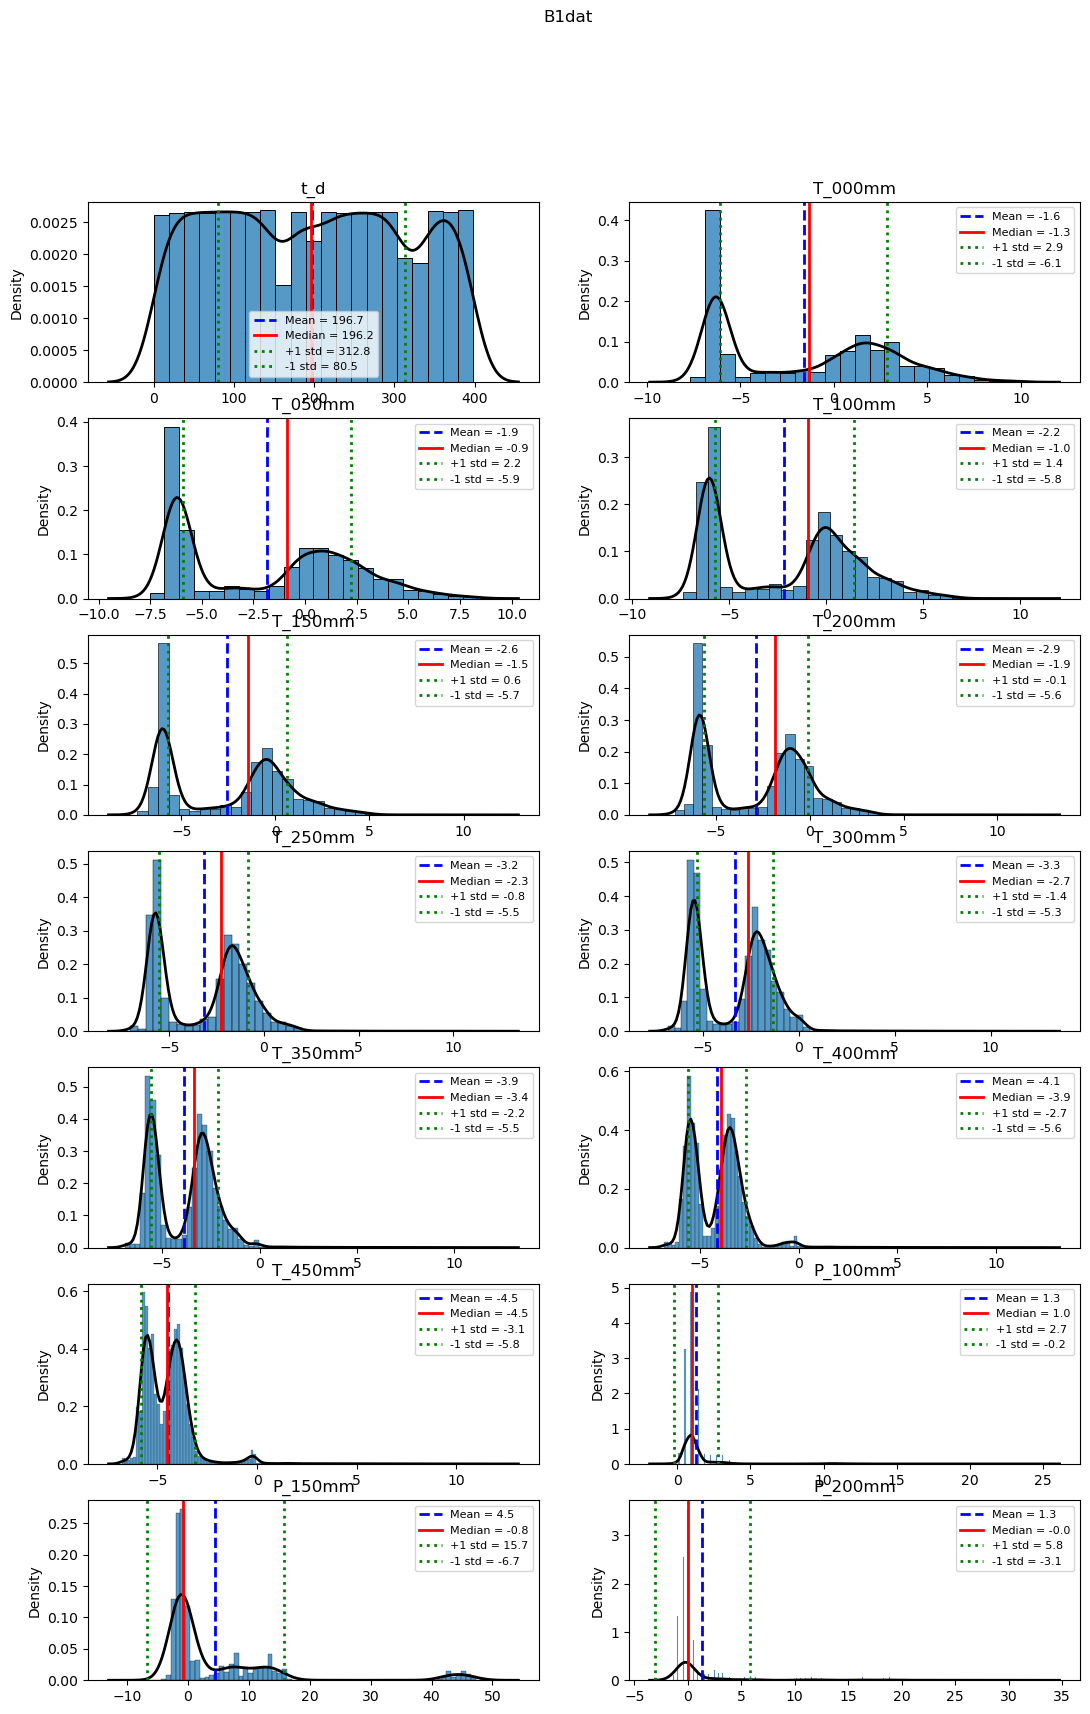

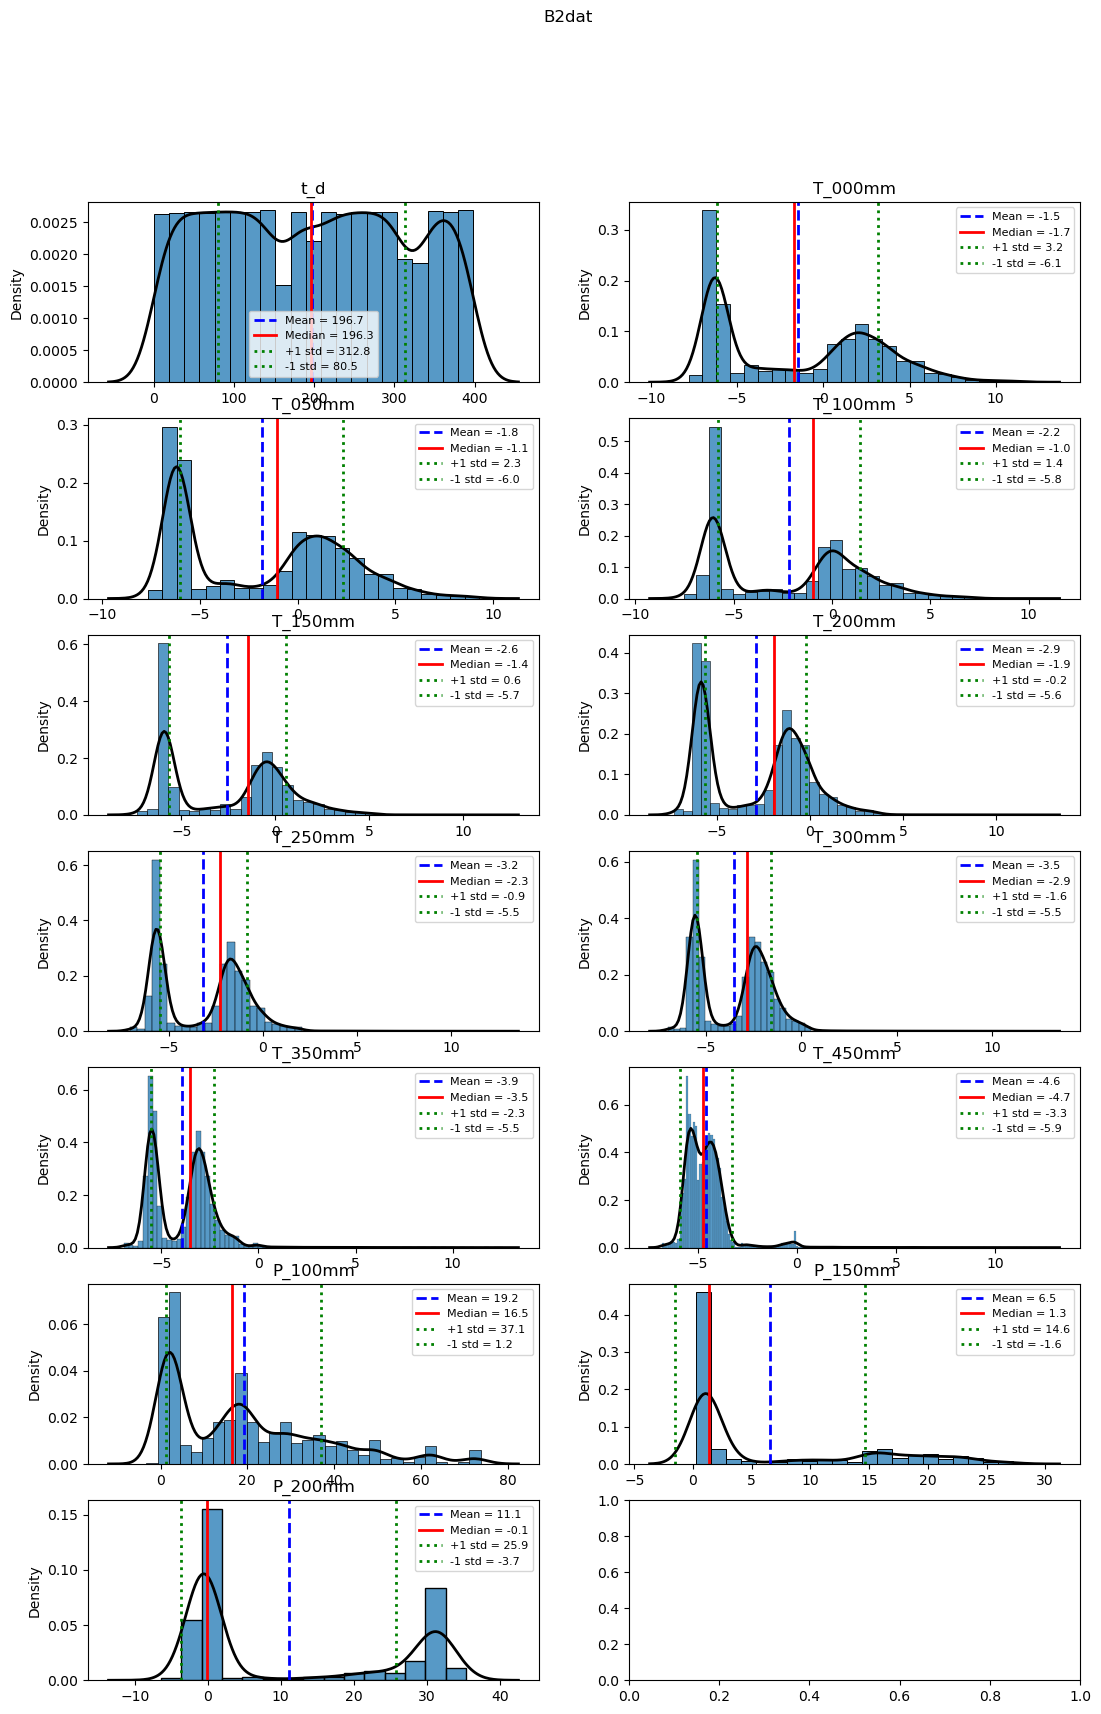

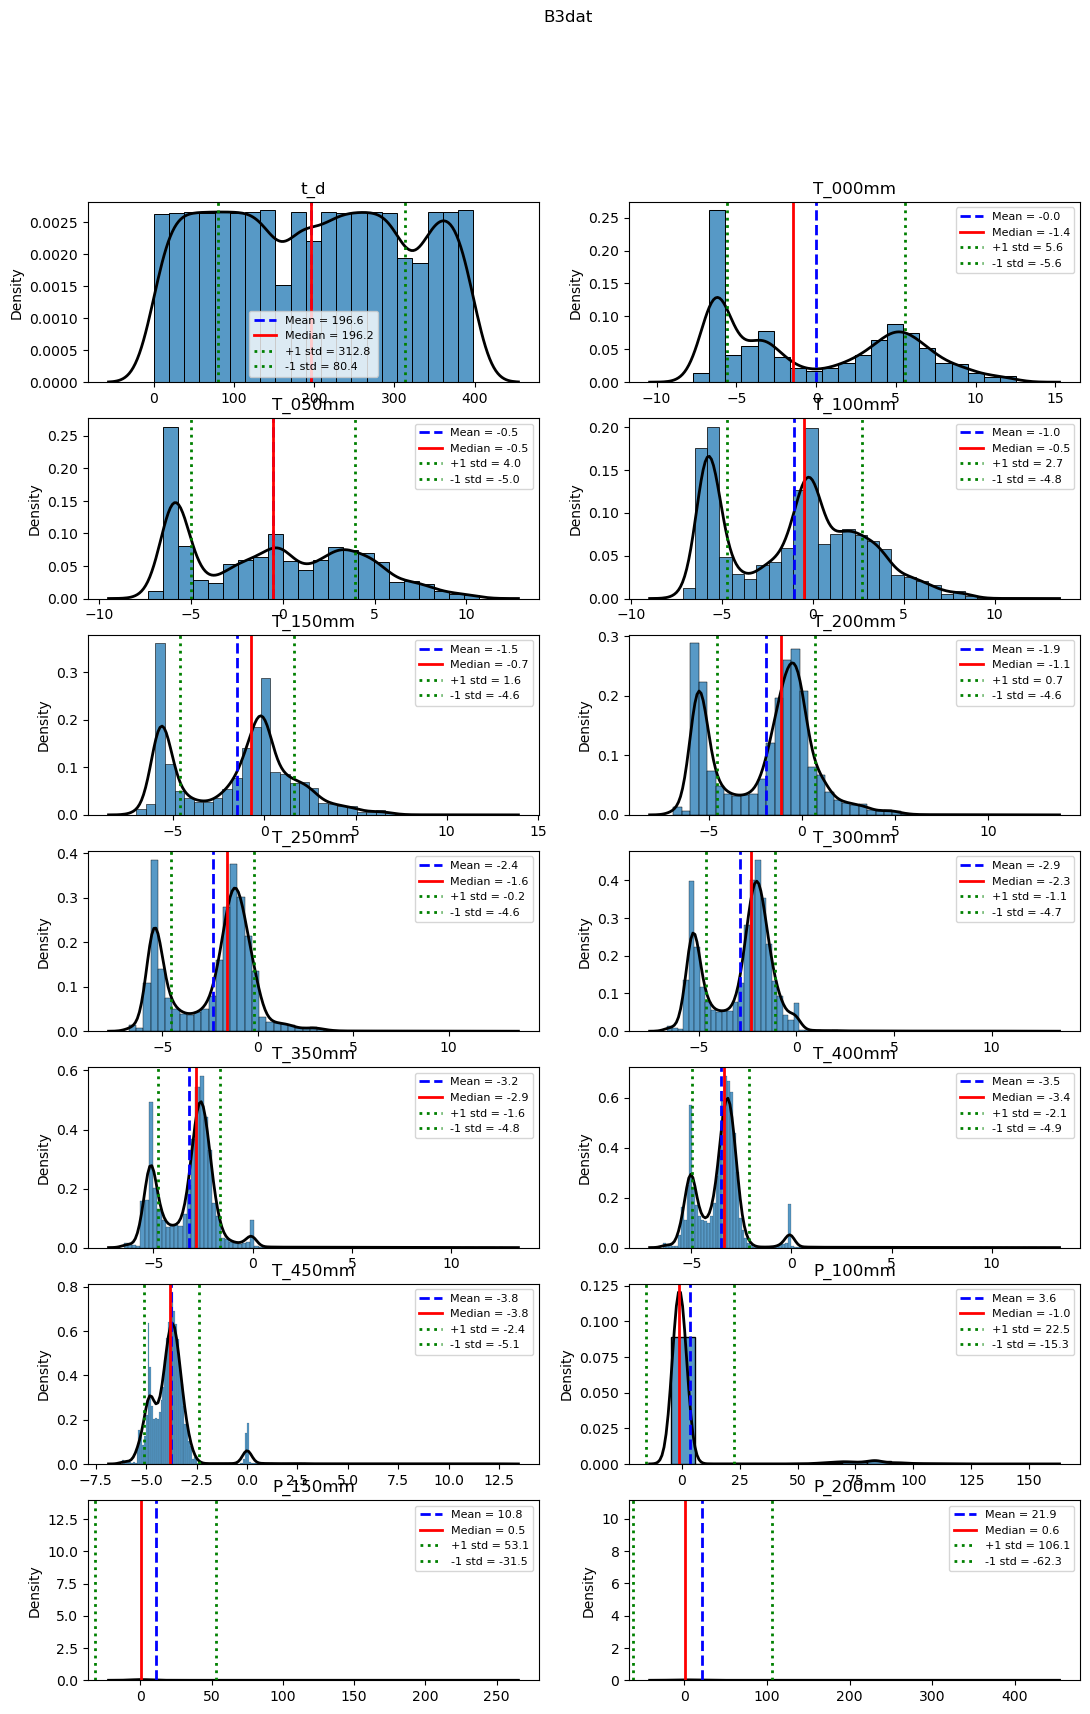

KeyboardInterrupt: 

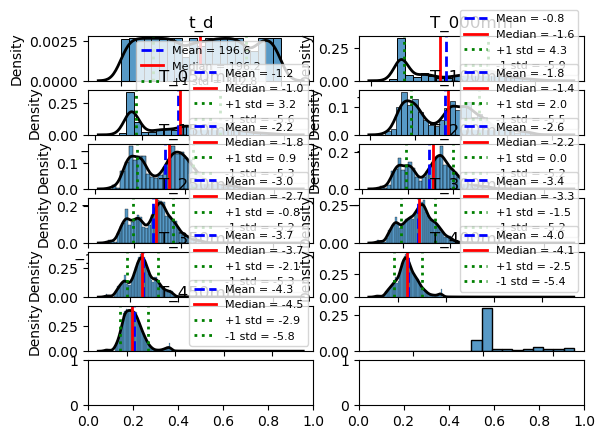

In [18]:
#exploratory data analysis
for name, data in [('B1dat',B1dat), ('B2dat',B2dat), ('B3dat',B3dat), ('B4dat',B4dat), \
                   ('U1dat',U1dat), ('U2dat',U2dat), ('U3dat',U3dat), ('U4dat',U4dat), ('U5dat',U5dat)]:
    fig, axes = plt.subplots(nrows=int(math.ceil(data.shape[1]/2)), ncols=2)
    axes = axes.flat
    for col, ax in zip(data.columns, axes):
        sns.histplot(data=data, x=col, ax=ax, stat='density')
        sns.kdeplot(data=data, x=col, ax=ax, color='k', linewidth=2)
    
        mean = np.mean(data[col])
        median = np.median(data[col])
        std = np.std(data[col])
        
        ax.axvline(mean, color='b', linestyle='--', lw=2, label=f'Mean = {mean:.1f}')
        ax.axvline(median, color='r', linestyle='-', lw=2, label=f'Median = {median:.1f}')
        ax.axvline(mean+std, color='g', linestyle=':', lw=2, label=f'+1 std = {(mean+std):.1f}')
        ax.axvline(mean-std, color='g', linestyle=':', lw=2, label=f'-1 std = {(mean-std):.1f}')
        
        ax.set_title(col)
        ax.set_xlabel('')
        ax.legend(fontsize=8)
    
    fig.set_figwidth(fig.get_figwidth() * 2)
    fig.set_figheight(fig.get_figheight() * 4)
    fig.suptitle(name)
    plt.savefig(f'raw_histograms_{name}.png', dpi=600, bbox_inches='tight')
    plt.show()

In [ ]:
# corr matrices
for name, data in [('B1dat',B1dat), ('B2dat',B2dat), ('B3dat',B3dat), ('B4dat',B4dat), \
                   ('U1dat',U1dat), ('U2dat',U2dat), ('U3dat',U3dat), ('U4dat',U4dat), ('U5dat',U5dat)]:
    # plot correlation matrix to inspect features for all modules
    feature_cols = data.columns
    corr_matrix = data[feature_cols].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='rainbow', vmin=0, vmax=1)
    plt.title(f'{name} Feature Correlation Matrix')
    plt.savefig(f'corr_matrix_{name}.png', dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [23]:
#add a time in seconds 't_s' column
for name, data in [('B1dat',B1dat), ('B2dat',B2dat), ('B3dat',B3dat), ('B4dat',B4dat), \
                   ('U1dat',U1dat), ('U2dat',U2dat), ('U3dat',U3dat), ('U4dat',U4dat), ('U5dat',U5dat)]:
    data['t_s'] = data['t_d']*86400

In [24]:
# extract depth from column header
def depth_list_from_cols(dataframe):
    T_depths = []
    P_depths = []
    
    for col in dataframe.columns:
        col = str(col)
        if col.startswith('T_') and 'mm' in col:
            d = col.split('_')[-1].replace('mm', '')
            T_depths.append(int(d))
        elif col.startswith('P_') and 'mm' in col:
            d = col.split('_')[-1].replace('mm', '')
            P_depths.append(int(d))
    
    return T_depths, P_depths

In [25]:
# define constants
v_s = 0.00109 #m³/kg #specific volume of ice
v_L = 0.00100 #\\    #specific volume of water
PI = np.pi
g = 9.80665
T_abs=273.15 #K
L_f=3.334e5 #J/kg #heat of fusion of ice
G = 100 #C/m #temp gradient as constant
K_star_ratio = 0.3 #taken as constant
T_f = -0.75 #C #temperature of the frozen fringe (freezing threshold)
k1_inv = 1e12
k2 = 1.0
Vc = 50e-9 #m/s converted from nm/s
gamma = 22



In [26]:
# build rock properties
rock_type = {'st_bees_ss'         : ['U1','B2'],
             'cove_red_ss'        : ['U2','B1'],
             'totternhoe_clunch'  : ['U3','B3'],
             'monks_park_oolite'  : ['U4','B4'],
             'tuffeau'            : ['U5']}

#reverse it
block_rock_type = {sample: rock for rock, samples in rock_type.items() for sample in samples}

# properties
props_by_rock = {'st_bees_ss':       {'nu': 0.2111, 'mu': 12.0e9, 'Kc': 0.50e6, 'R_g': 0.364e-3},
                'cove_red_ss':       {'nu': 0.2111, 'mu': 12.0e9, 'Kc': 0.48e6, 'R_g': 0.364e-3},
                'totternhoe_clunch': {'nu': 0.2200, 'mu': 22.0e9, 'Kc': 0.24e6, 'R_g': 0.426e-3},
                'monks_park_oolite': {'nu': 0.2200, 'mu': 22.0e9, 'Kc': 0.39e6, 'R_g': 0.426e-3},
                'tuffeau':           {'nu': 0.2200, 'mu': 22.0e9, 'Kc': 0.20e6, 'R_g': 0.426e-3},}

#Rf_min
Rf_min = {'U1': 2.0e14,
          'U2': 3.0e14,
          'U3': 2.0e14,
          'U4': 3.0e14,
          'U5': 4.0e14,
          'B1': 6.0e14,
          'B2': 7.0e14,
          'B3': 8.0e14,
          'B4': 3.0e15}

In [27]:
# walder-hallet model
def run_walder_hallet(dataframe, block_str: str):
    '''
    takes the dataframe and which block it is. and takes the current KI, p_i, c, and w for time=t
    returns KI, Vs, c, and w for time=t+1
    '''
    #assign rock properties
    rock_type = block_rock_type[block_str]
    nu = props_by_rock[rock_type]['nu']
    mu = props_by_rock[rock_type]['mu']
    Kc = props_by_rock[rock_type]['Kc']
    R_g = props_by_rock[rock_type]['R_g']

    #Rf_min
    Rfmin = Rf_min[block_str]

    # calculate K_star
    K_star = K_star_ratio * Kc
    
    # extract series from dataframe
    ts = dataframe['t_s']
    Tc = dataframe[[col for col in dataframe.columns if col.startswith('T_')]]
    depths, _ = depth_list_from_cols(dataframe)

    # initial values
    c_0 = 5/1000 #m #assumed initial crack radius #5/1000 in W-H paper
    w_0 = 0.5/1000000 #m

    #initiate outputs
    c = np.full((len(ts), len(depths)), c_0, float)
    w = np.full((len(ts), len(depths)), w_0, float)
    p_i = np.zeros((len(ts), len(depths)), float)
    KI = np.zeros((len(ts), len(depths)), float)
    Vs = np.zeros((len(ts), len(depths)), float)
    
    # iterate over times
    for i in range(1,len(ts)):
        t0, t1 = ts[i-1], ts[i]
        # iterate over all depths at that time
        for j in range(len(depths)):
            Tc_now = Tc.iloc[i,j]
            
            #set up for Euler integration
            dt = t1 - t0
            
            # use previous state to compute derivatives
            c_prev = c[i-1, j]
            w_prev = w[i-1, j]
            p_i_prev = p_i[i-1, j]
            Vs_prev = Vs[i-1,j]

            #calculate crack growth only if freezing
            
            # Euler update
            if Tc_now <= T_f:  # freezing
                # need to solve for KI, p_i and Rf first
                # Rf from eqns 6–8
                Ifc = k1_inv * ((T_f**3 - Tc_now**3) / 3.0 - T_f * Tc_now * (T_f - Tc_now))
                Rf  = max(Ifc / abs(G) + (R_g**2) * (-Tc_now**2) / k2, Rfmin) #implemeted Rfmin
    
                # internal ice pressure from eqn 9 and 10
                tao = (8/(3*PI))*((1-nu)/mu)*((g*c_prev*v_L)/(v_s)**2)*Rf
                p_i[i,j] = (L_f*(-Tc_now))/(v_s*T_abs) * (1 - np.exp(-t1/tao))
                
                # KI from eqn 1
                KI[i,j] = np.sqrt(max(4.0*c_prev/PI, 0.0)) * p_i[i,j] #prevent negative square root
                
                # Vs from eqn 4
                Vs[i,j] = (((v_s**2)/(g*v_L))*(1.0/Rf)*(L_f*(-Tc_now)/(v_s*T_abs)) - p_i[i,j])
                
                # dc/dt from eqn 3
                if KI[i,j] > K_star:
                    dc_dt = Vc*(np.exp(gamma*((KI[i,j]/Kc)**2 - 1.0)) - np.exp(gamma*((K_star/Kc)**2 - 1.0)))
                else:
                    dc_dt = 0.0
                
                # dw/dt from eqn 5
                dw_dt = ((3.0*v_s**2)/(2.0*g*v_L))*(1.0/Rf)*((L_f*(-Tc_now)/(v_s*T_abs)) - p_i[i,j]) - 2*(w_prev/c_prev)*dc_dt
                
                c[i, j] = c_prev + (dc_dt * dt)
                w[i, j] = w_prev + (dw_dt * dt)
                
            else:  # thawing
                c[i, j] = c_prev #keep crack radius
                w[i, j] = w_0 #return to initial satate of closed crack
            
    # backfill KI[0,:] and Vs[0::]
    for j in range(len(depths)):
        Ifc0 = k1_inv*((T_f**3-Tc.iloc[0,j]**3)/3.0 - T_f*Tc.iloc[0,j]*(T_f-Tc.iloc[0,j]))
        Rf0 = max(Ifc0/abs(G) + (R_g**2)*(-Tc.iloc[0,j]**2)/k2, Rfmin)
        Vs[0,j] = (((v_s**2)/(g*v_L))*(1.0/Rf0)*(L_f*(-Tc.iloc[0,j])/(v_s*T_abs)))

    return c, w, KI, Vs

In [28]:
# c_B1, w_B1, KI_B1, Vs_B1 = run_walder_hallet(B1dat, 'B1')
# c_B2, w_B2, KI_B2, Vs_B2 = run_walder_hallet(B2dat, 'B2')
# c_B3, w_B3, KI_B3, Vs_B3 = run_walder_hallet(B3dat, 'B3')
# c_B4, w_B4, KI_B4, Vs_B4 = run_walder_hallet(B4dat, 'B4')
# c_U1, w_U1, KI_U1, Vs_U1 = run_walder_hallet(U1dat, 'U1')
# c_U2, w_U2, KI_U2, Vs_U2 = run_walder_hallet(U2dat, 'U2')
# c_U3, w_U3, KI_U3, Vs_U3 = run_walder_hallet(U3dat, 'U3')
# c_U4, w_U4, KI_U4, Vs_U4 = run_walder_hallet(U4dat, 'U4')
# c_U5, w_U5, KI_U5, Vs_U5 = run_walder_hallet(U5dat, 'U5')

In [29]:
# wanted_depths = [50, 150, 250, 350]

# for name, data, Vs in [('B1',B1dat,Vs_B1), ('B2',B2dat,Vs_B2), ('B3',B3dat,Vs_B3), ('B4',B4dat,Vs_B4), \
#                    ('U1',U1dat,Vs_U1), ('U2',U2dat,Vs_U2), ('U3',U3dat,Vs_U3), ('U4',U4dat,Vs_U4), ('U5',U5dat,Vs_U5)]:
#     depths, _ = depth_list_from_cols(data)
#     Vs_df = pd.DataFrame(Vs)
#     smoothed_data = Vs_df.rolling(window=21, center=True).median()
#     smoothed_data = smoothed_data.to_numpy()
#     plt.figure(figsize=(20, 6))
#     for j, depth in enumerate(depths):
#         if depth in wanted_depths:
#             plt.plot(data['t_d'], smoothed_data[:, j], label=f'{depth} mm')
#     #plt.yscale('log')
#     plt.xlabel('Time (days)')
#     plt.ylabel('Rate of added ice volume to cracks (m/s)')
#     plt.ylim(np.min(Vs)/2, np.max(Vs))
#     plt.title(F"{name}:'{block_rock_type[name]}' Vs over time')
#     plt.legend()
#     plt.savefig(f'Vs_{name}.png', dpi=400, bbox_inches='tight')
#     plt.show()

In [30]:
# wanted_depths = [50, 150, 250, 350]

# for name, data, w in [('B1',B1dat,w_B1), ('B2',B2dat,w_B2), ('B3',B3dat,w_B3), ('B4',B4dat,w_B4), \
#                    ('U1',U1dat,w_U1), ('U2',U2dat,w_U2), ('U3',U3dat,w_U3), ('U4',U4dat,w_U4), ('U5',U5dat,w_U5)]:
#     depths, _ = depth_list_from_cols(data)
#     w_df = pd.DataFrame(w)
#     smoothed_data = w_df.rolling(window=21, center=True).median()
#     smoothed_data = smoothed_data.to_numpy()
#     plt.figure(figsize=(20, 6))
#     for j, depth in enumerate(depths):
#         if depth in wanted_depths:
#             plt.plot(data['t_d'], smoothed_data[:, j], label=f'{depth} mm')
#     plt.yscale('log')
#     plt.xlabel('Time (days)')
#     plt.ylabel('Crack width (qualitative)')
#     plt.ylim(0, np.max(w))
#     plt.title(F"{name}:'{block_rock_type[name]}' Crack width over time")
#     plt.legend()
#     #plt.savefig(f'w_{name}.png', dpi=400, bbox_inches='tight')
#     plt.show()

In [31]:
# walder-hallet model with RK23
def run_walder_hallet_with_ODE(dataframe, block_str: str):
    '''
    takes the dataframe and which block it is. and takes the current KI, p_i, c, and w for time=t
    returns KI, p_i, c, and w for time=t+1
    '''
    #assign rock properties
    rock_type = block_rock_type[block_str]
    nu = props_by_rock[rock_type]['nu']
    mu = props_by_rock[rock_type]['mu']
    Kc = props_by_rock[rock_type]['Kc']
    R_g = props_by_rock[rock_type]['R_g']

    #Rf_min
    Rfmin = Rf_min[block_str]

    # calculate K_star
    K_star = K_star_ratio * Kc
    
    # extract series from dataframe
    ts = dataframe['t_s']
    Tc = dataframe[[col for col in dataframe.columns if col.startswith('T_')]]
    depths, _ = depth_list_from_cols(dataframe)

    # initial values
    c_0 = 5/1000 #m #assumed initial crack radius #5/1000 in W-H paper
    w_0 = 0.5/1000000 #m

    #initiate outputs
    c = np.full((len(ts), len(depths)), c_0, float)
    w = np.full((len(ts), len(depths)), w_0, float)
    KI = np.zeros((len(ts), len(depths)), float)
    Vs = np.zeros((len(ts), len(depths)), float)

    # define right hand side of eqn in a function
    def RHS(j):
        def f(t, y): #needed for solve_ivp
            Tc_func = Tc.iloc[:,j].to_numpy()
            ts_func = ts.to_numpy()
            c_func, w_func = y
            Tc_now_func = np.interp(t, ts_func, Tc_func)
            
            if Tc_now_func <= T_f: #freezing cycle
                # need to solve for KI, p_i and Rf first

                #eqn 8, 7 and 6
                Ifc_func = k1_inv*((T_f**3-Tc_now_func**3)/3.0 - T_f*Tc_now_func*(T_f-Tc_now_func))
                Rf_func = max(Ifc_func/abs(G) + (R_g**2)*(-Tc_now_func**2)/k2 , Rfmin)
                
                # internal ice pressure from eqn 9 and 10
                tao_func = (8/(3*PI))*((1-nu)/mu)*((g*c_func*v_L)/(v_s)**2)*Rf_func
                p_i_func = (L_f*(-Tc_now_func))/(v_s*T_abs) * (1 - np.exp(-t/tao_func))
                
                #eqn 1
                KI_func = np.sqrt(max(4.0*c_func/PI, 0.0))*p_i_func
                
                #now calculate dc/dt and dw/dt
                # eqn 3
                if KI_func > K_star: #crack grows
                    dc_func = Vc*(np.exp(gamma*((KI_func/Kc)**2 - 1.0)) - np.exp(gamma*((K_star/Kc)**2 - 1.0)))
                else: #crack doesn't grow
                    dc_func = 0.0
                
                # eqn 5
                dw_func = (((3.0*v_s**2)/(2.0*g*v_L))*(1.0/Rf_func)*(L_f*(-Tc_now_func)/(v_s*T_abs)) - p_i_func) *dc_func
            else:
                return [0.0, 0.0]
            return[dc_func, dw_func]
        return f
    
    # iterate over times
    for i in range(1,len(ts)): #start from step 1 to have t0 and t1 values
        t0, t1 = ts[i-1], ts[i]
        
        # iterate over all depths at that time
        for j in range(len(depths)):
            #fetch current crack temperature 
            Tc_now = Tc.iloc[i,j]
            # detect freezing cycle
            if Tc_now <= T_f:
                # integrate using solve_ivp
                soln = solve_ivp(RHS(j), (t0, t1), [c[i-1,j],w[i-1,j]], t_eval=[t1], \
                                 method='RK23', rtol=1e-6, atol=1e-10)
                c[i,j] = soln.y[0,-1] if soln.success else c[i-1,j]
                w[i,j] = soln.y[1,-1] if soln.success else w[i-1,j]
            else: # thawing cycle
                c[i,j] = c[i-1,j]
                w[i,j] = 0.5/1000000 #return to initial width

            # record KI and Vs at the *new* time
            Ifc = k1_inv*((T_f**3 - Tc_now**3)/3.0 - T_f*Tc_now*(T_f - Tc_now))
            Rf = max(Ifc/abs(G) + (R_g**2)*(-Tc_now**2)/k2, Rfmin)
            tao = (8/(3*PI))*((1-nu)/mu)*((g*c[i,j]*v_L)/(v_s)**2)*Rf
            p_i = (L_f*(-Tc_now))/(v_s*T_abs) * (1 - np.exp(-t1/tao))
            KI[i,j] = np.sqrt(4*c[i,j]/PI)*p_i
            
            # calculate VS from eqn 4
            Vs[i,j] = (((v_s**2)/(g*v_L))*(1.0/Rf)*(L_f*(-Tc_now)/(v_s*T_abs)) - p_i)

    # backfill KI[0,:] because we started from step 1.
    for j in range(len(depths)):
        Ifc0 = k1_inv*((T_f**3-Tc.iloc[0,j]**3)/3.0 - T_f*Tc.iloc[0,j]*(T_f-Tc.iloc[0,j]))
        Rf0 = max(Ifc0/abs(G) + (R_g**2)*(-Tc.iloc[0,j]**2)/k2, Rfmin)
        Vs[0,j] = ((v_s**2)/(g*v_L))*(1.0/Rf0)*(L_f*(-Tc.iloc[0,j])/(v_s*T_abs))

    return c, w, KI, Vs

In [32]:
sc_B1, sw_B1, sKI_B1, sVs_B1 = run_walder_hallet_with_ODE(B1dat, 'B1')
sc_B2, sw_B2, sKI_B2, sVs_B2 = run_walder_hallet_with_ODE(B2dat, 'B2')
sc_B3, sw_B3, sKI_B3, sVs_B3 = run_walder_hallet_with_ODE(B3dat, 'B3')
sc_B4, sw_B4, sKI_B4, sVs_B4 = run_walder_hallet_with_ODE(B4dat, 'B4')
sc_U1, sw_U1, sKI_U1, sVs_U1 = run_walder_hallet_with_ODE(U1dat, 'U1')
sc_U2, sw_U2, sKI_U2, sVs_U2 = run_walder_hallet_with_ODE(U2dat, 'U2')
sc_U3, sw_U3, sKI_U3, sVs_U3 = run_walder_hallet_with_ODE(U3dat, 'U3')
sc_U4, sw_U4, sKI_U4, sVs_U4 = run_walder_hallet_with_ODE(U4dat, 'U4')
sc_U5, sw_U5, sKI_U5, sVs_U5 = run_walder_hallet_with_ODE(U5dat, 'U5')

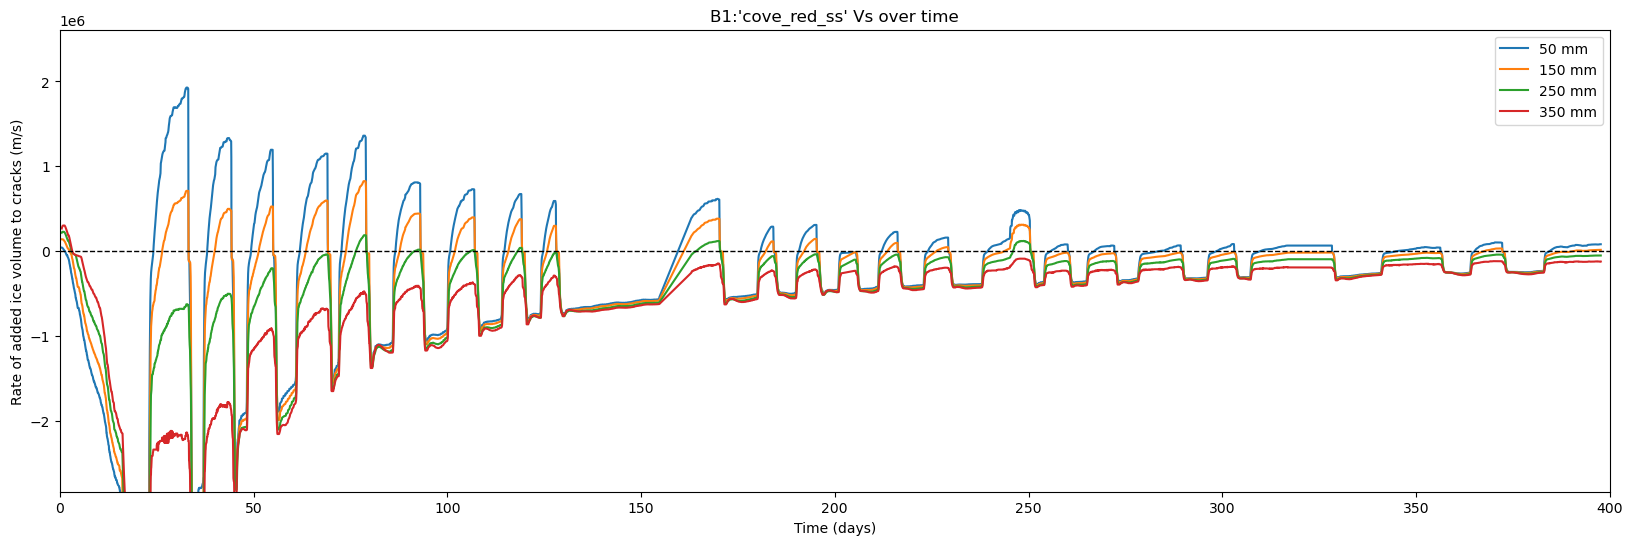

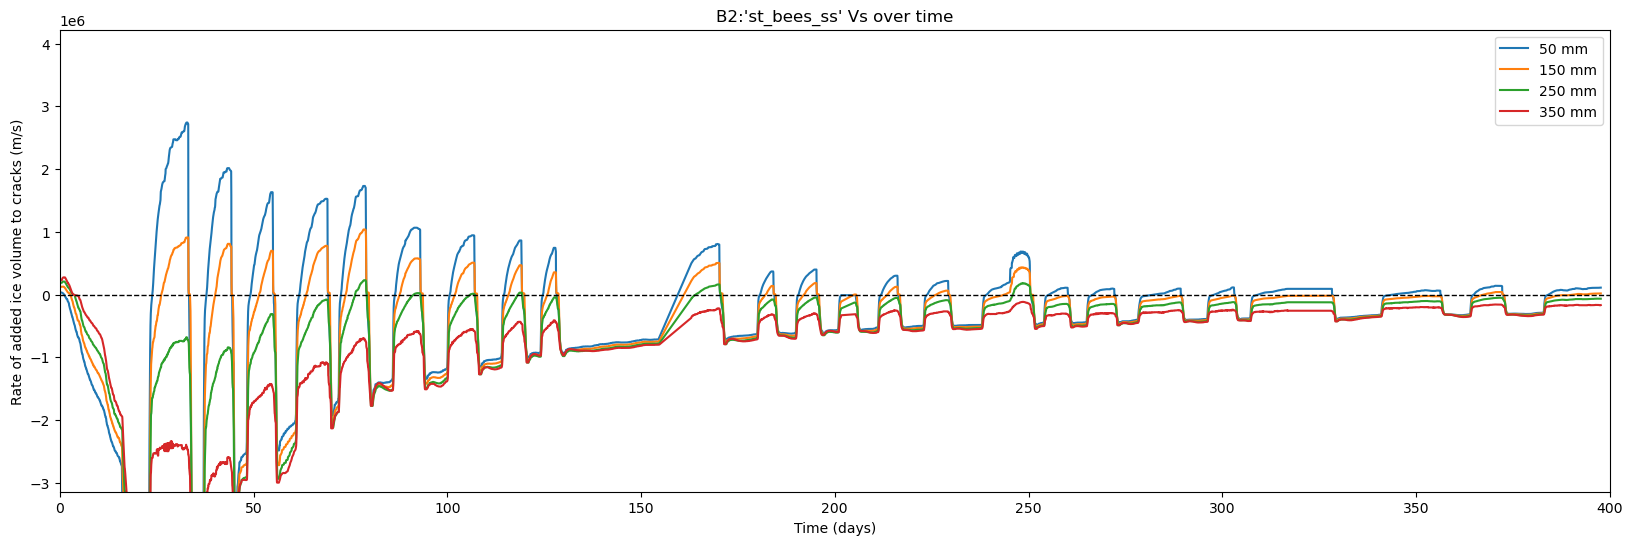

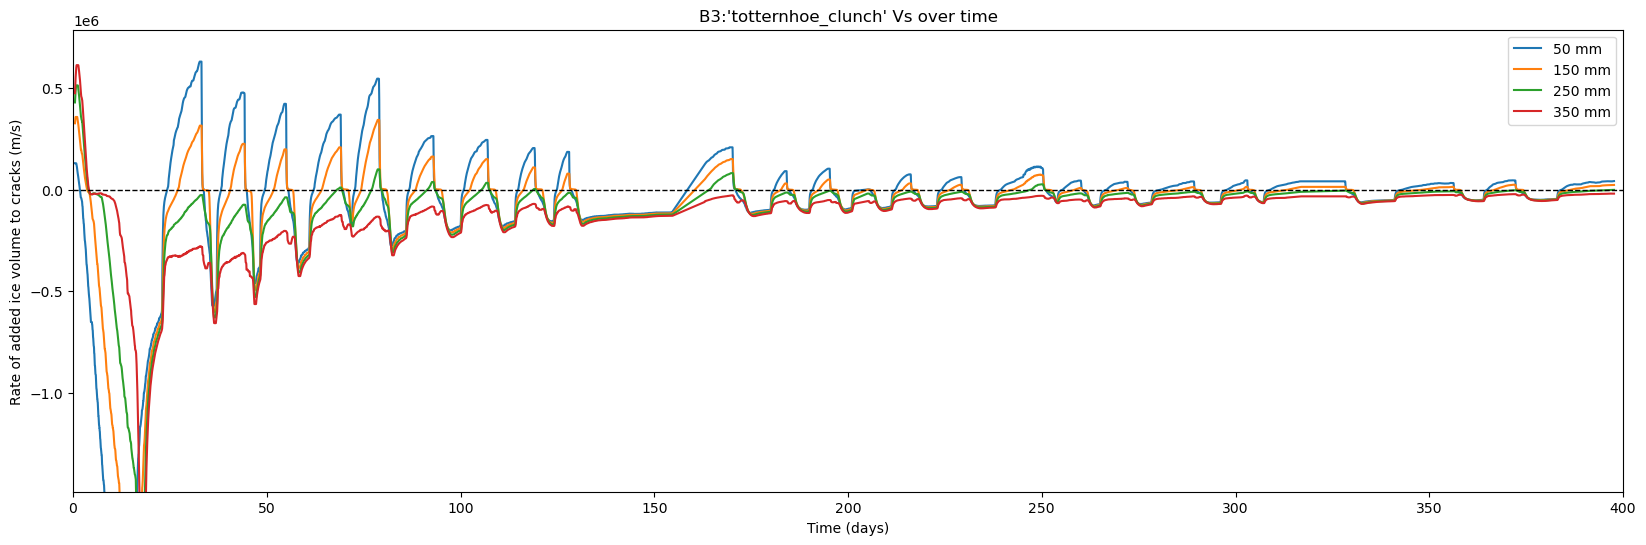

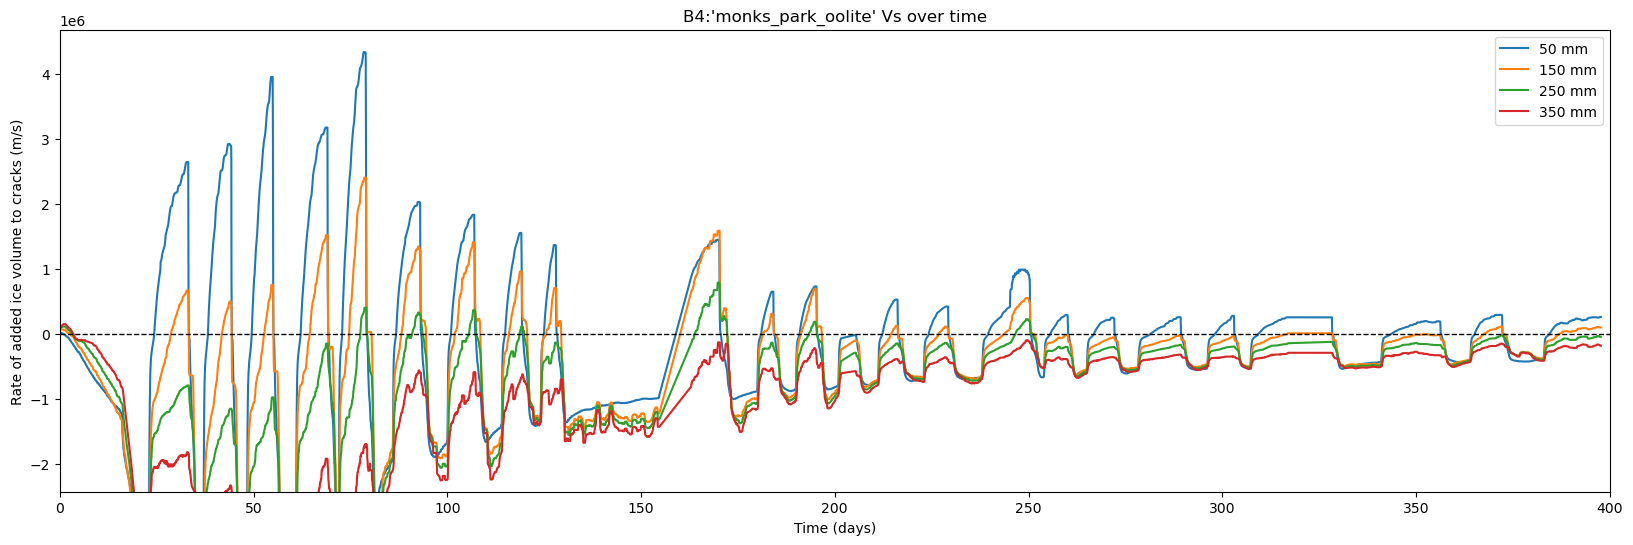

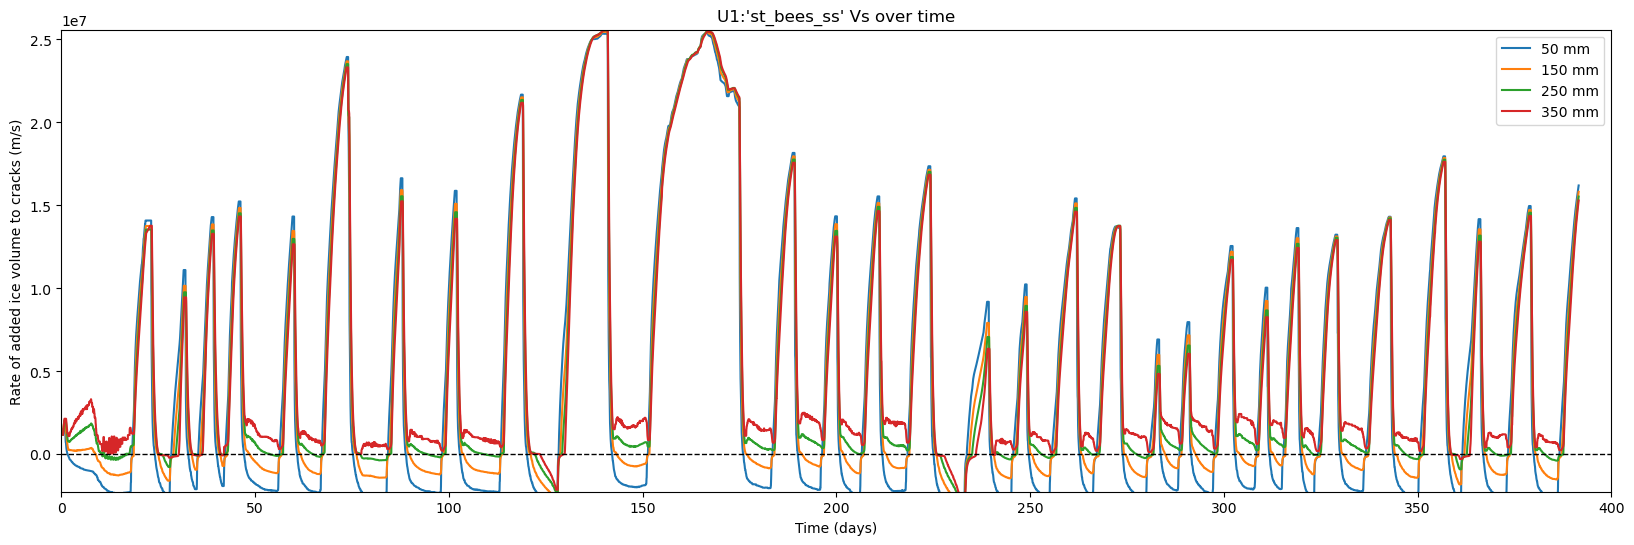

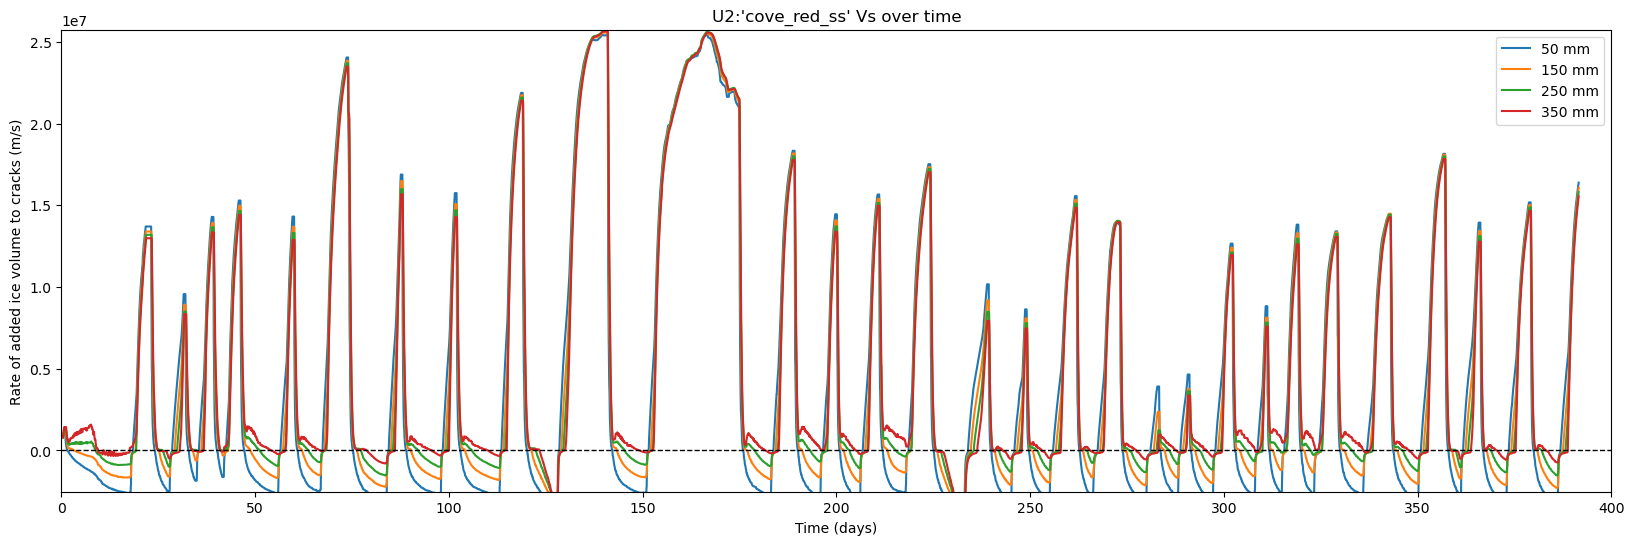

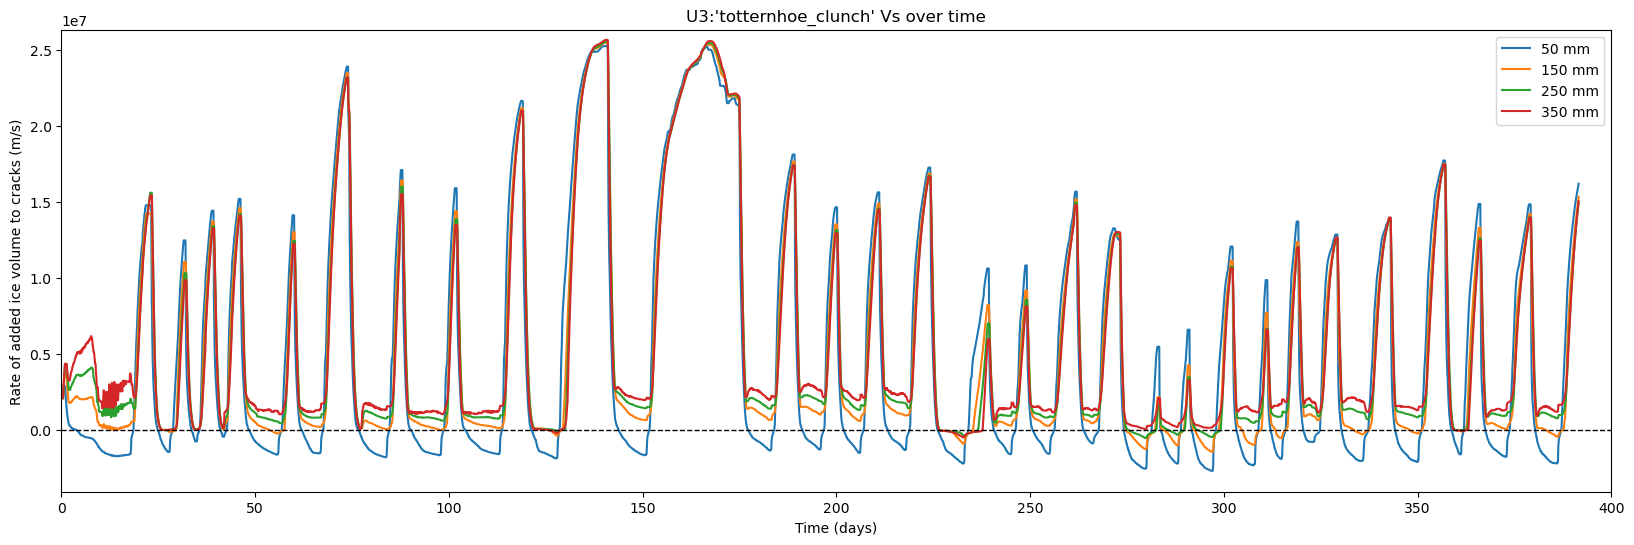

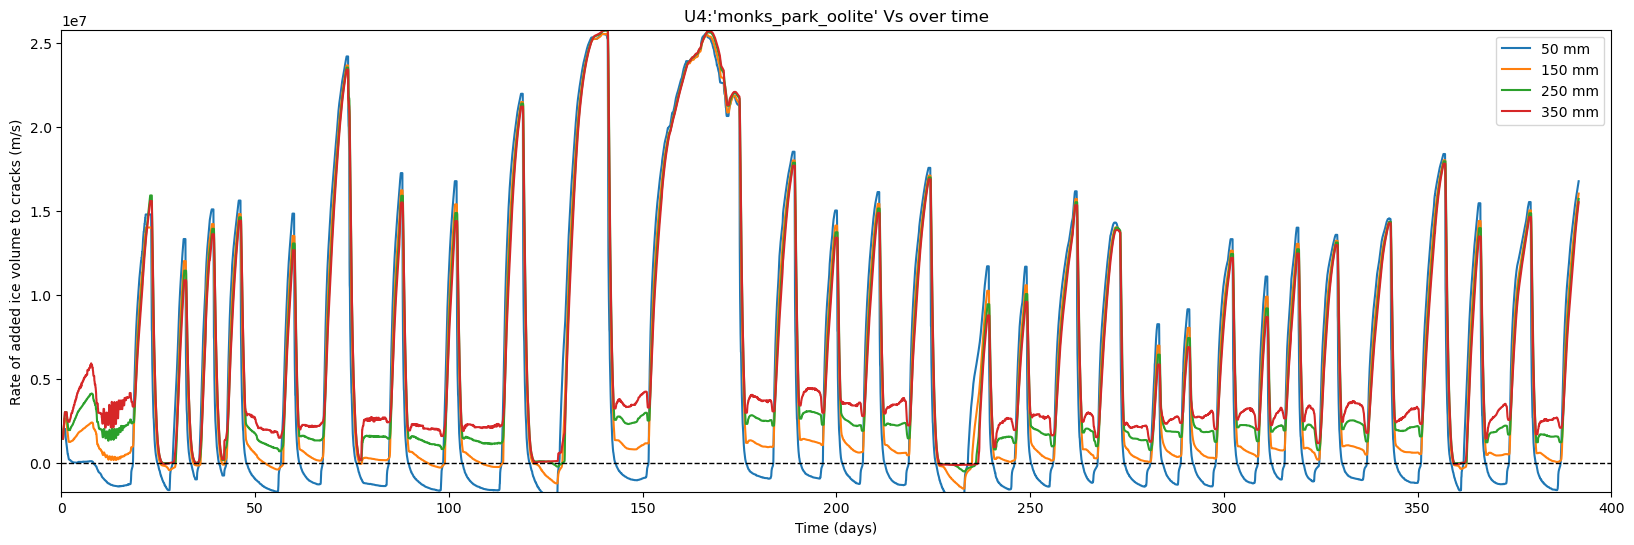

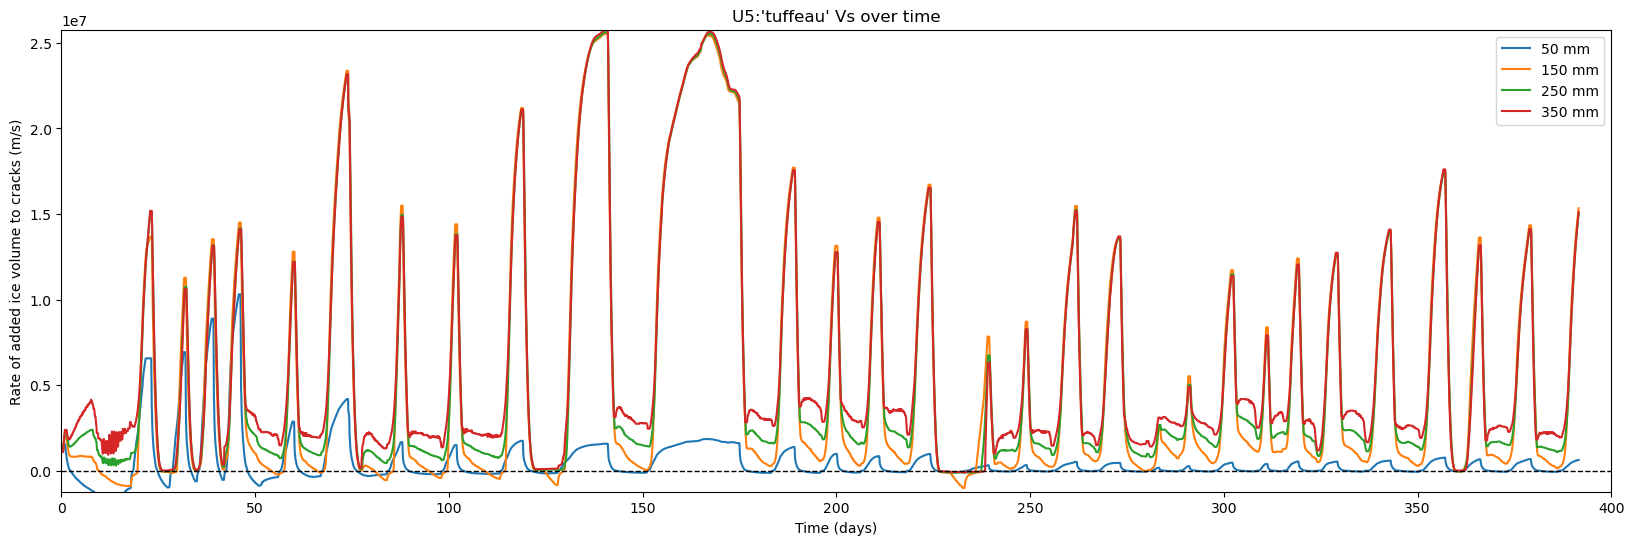

In [48]:
wanted_depths = [50, 150, 250, 350]

for name, data, Vs in [('B1',B1dat,sVs_B1), ('B2',B2dat,sVs_B2), ('B3',B3dat,sVs_B3), ('B4',B4dat,sVs_B4), \
                   ('U1',U1dat,sVs_U1), ('U2',U2dat,sVs_U2), ('U3',U3dat,sVs_U3), ('U4',U4dat,sVs_U4), ('U5',U5dat,sVs_U5)]:
    depths, _ = depth_list_from_cols(data)
    Vs_df = pd.DataFrame(Vs)
    smoothed_data = Vs_df.rolling(window=21, center=True).median()
    smoothed_data = smoothed_data.to_numpy()
    plt.figure(figsize=(20, 6))
    for j, depth in enumerate(depths):
        if depth in wanted_depths:
            plt.plot(data['t_d'], smoothed_data[:, j], label=f'{depth} mm')
    #plt.yscale('log')
    plt.xlabel('Time (days)')
    plt.ylabel('Rate of added ice volume to cracks (m/s)')
    plt.ylim(np.min(Vs_df)/2, np.max(Vs_df))
    plt.xlim(0, 400)
    plt.hlines(0,0,400, ls='--', lw=1, color='k')
    plt.title(F"{name}:'{block_rock_type[name]}' Vs over time")
    plt.legend()
    plt.savefig(f'Vs_{name}.png', dpi=400, bbox_inches='tight')
    plt.show()

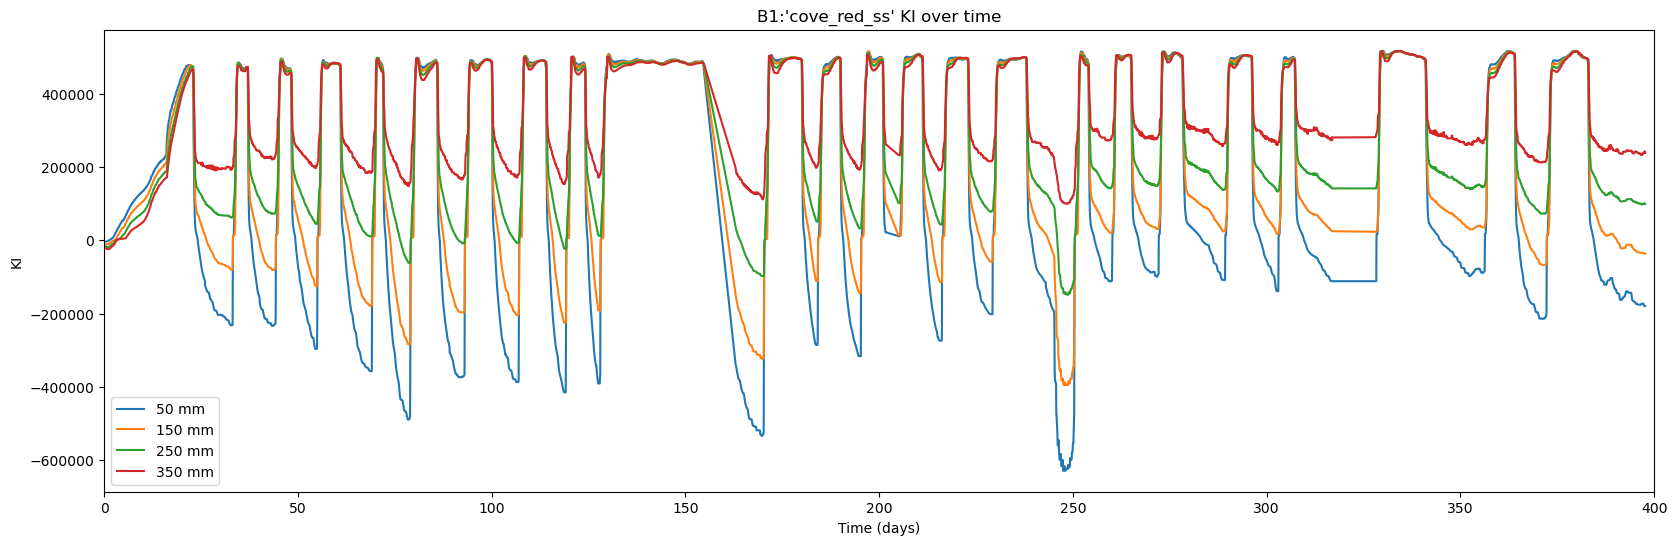

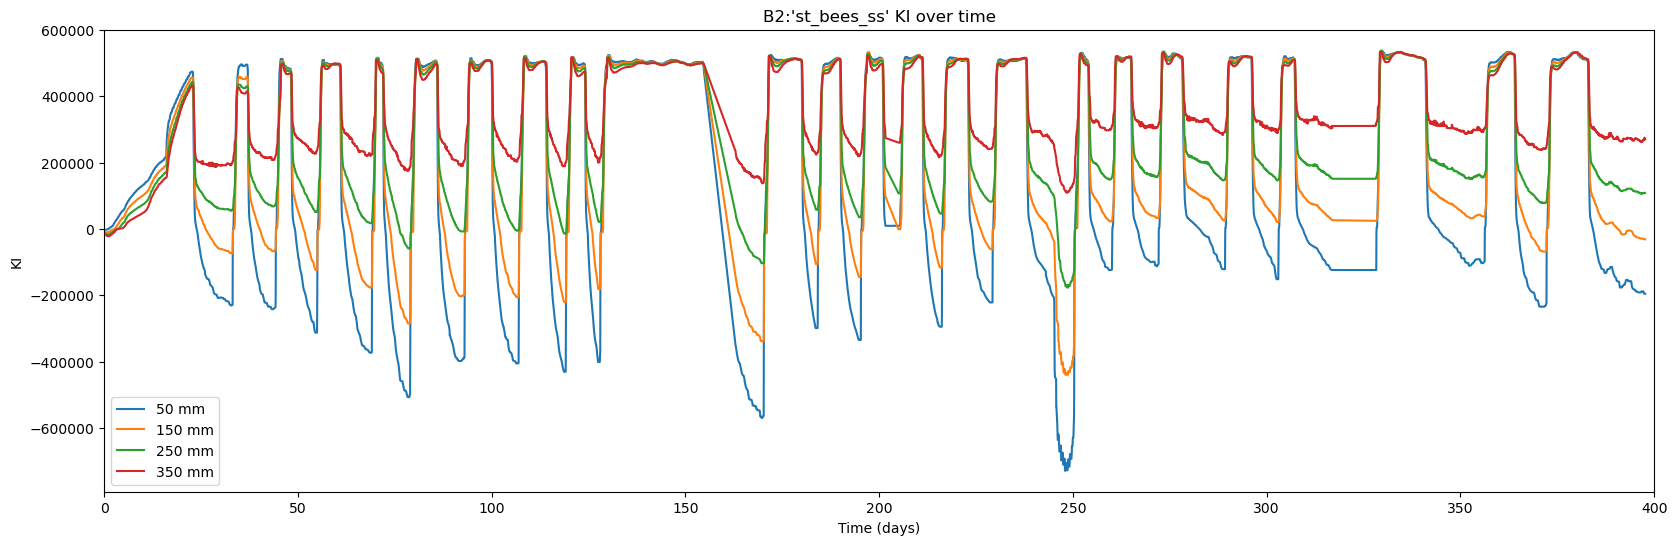

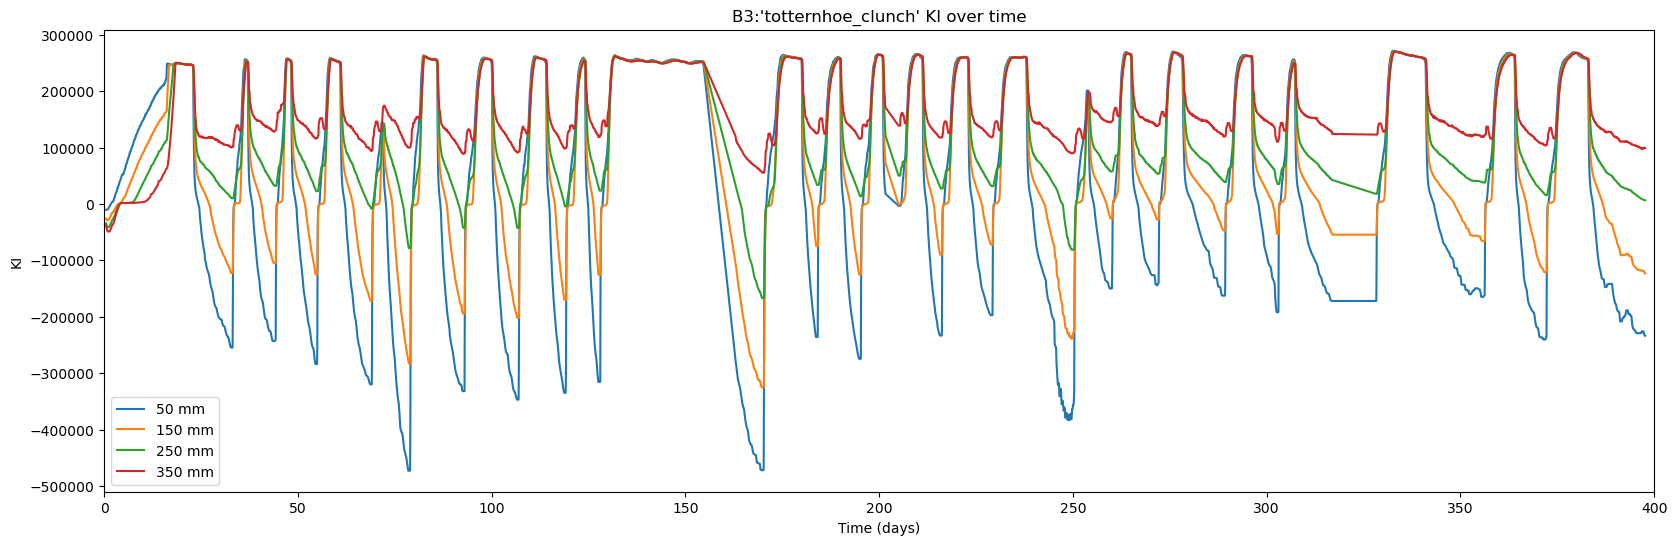

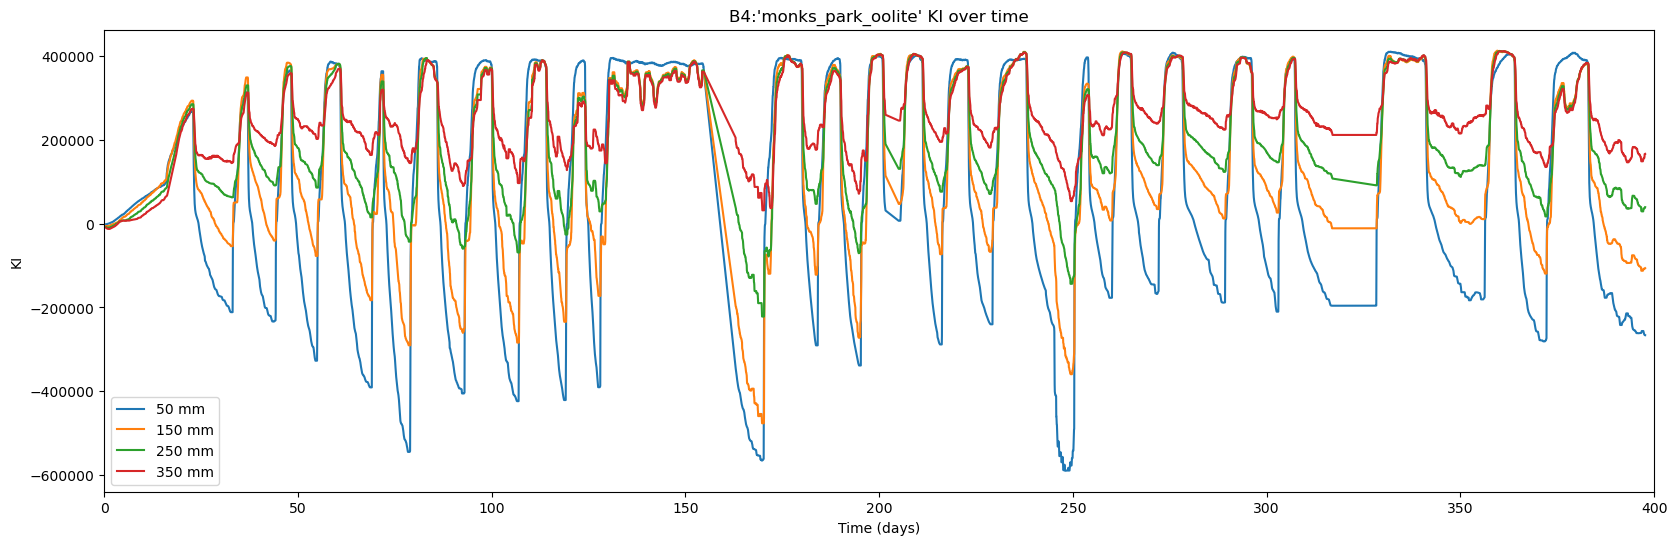

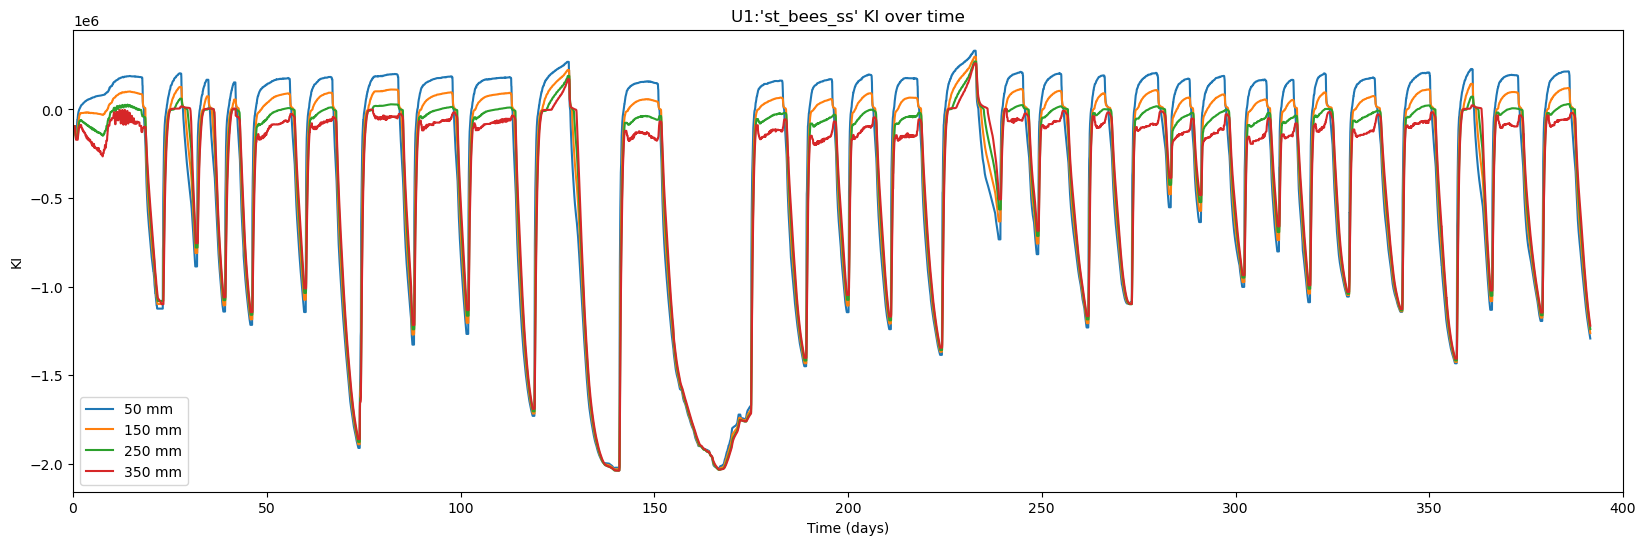

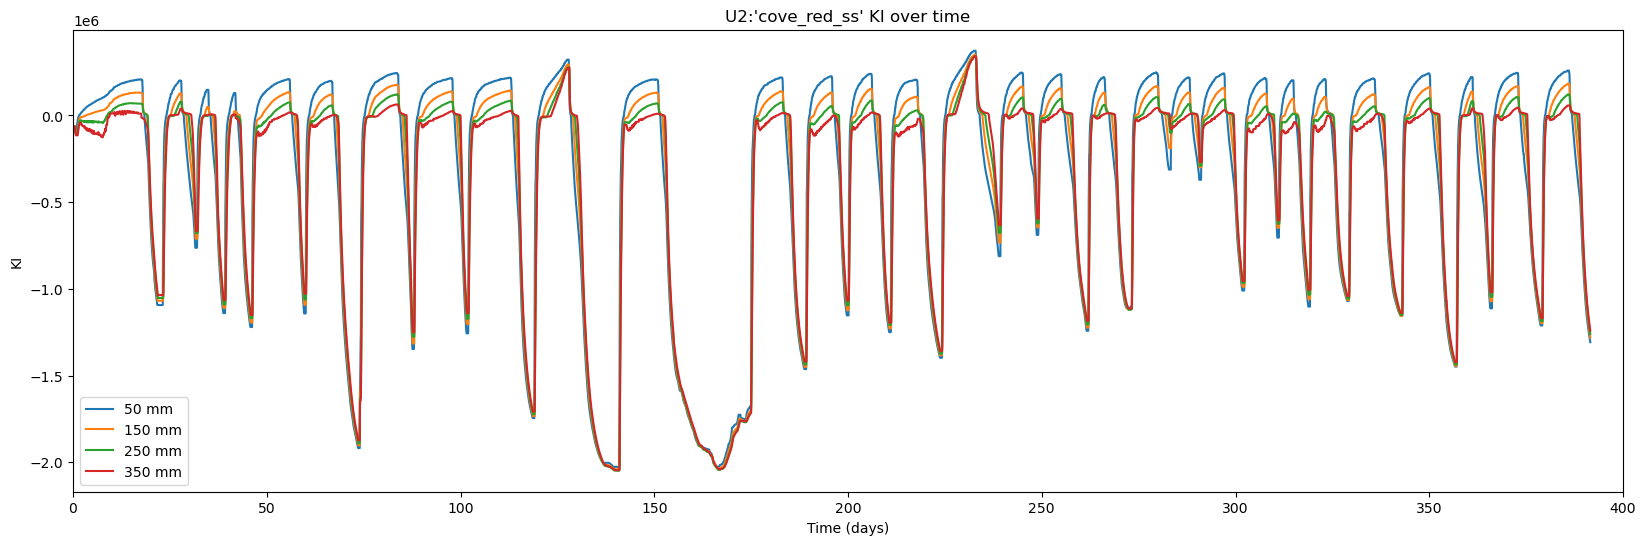

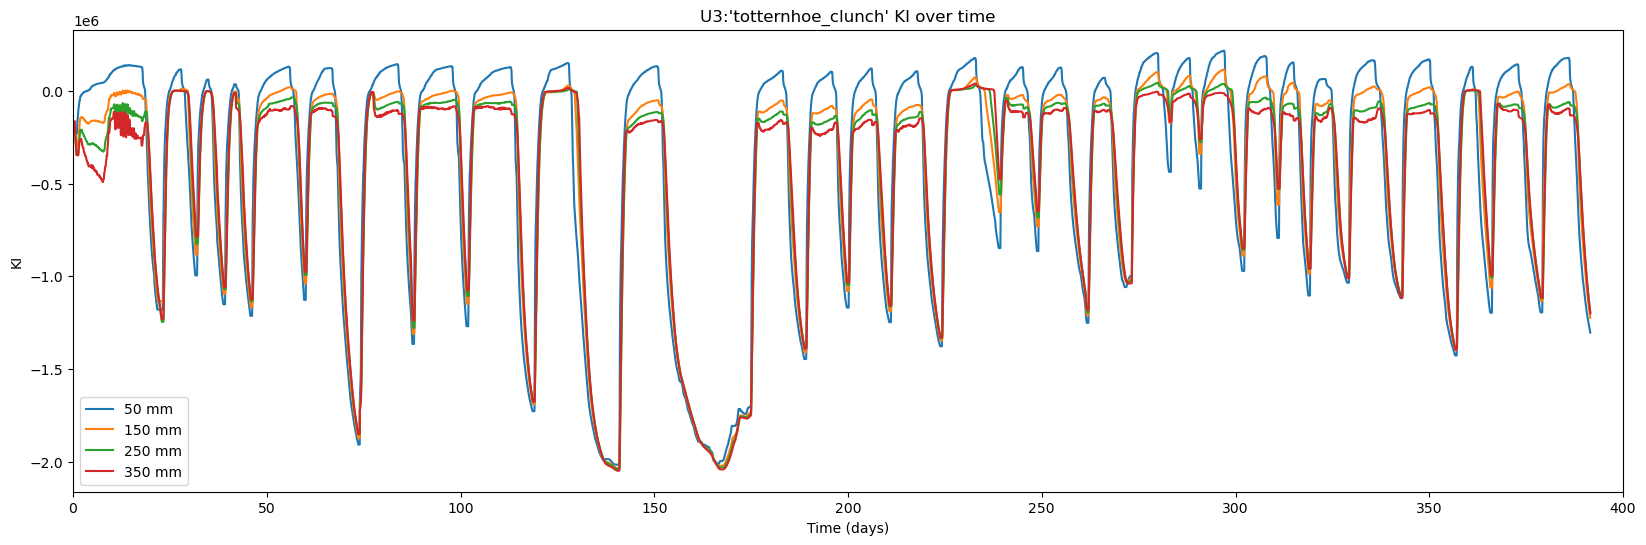

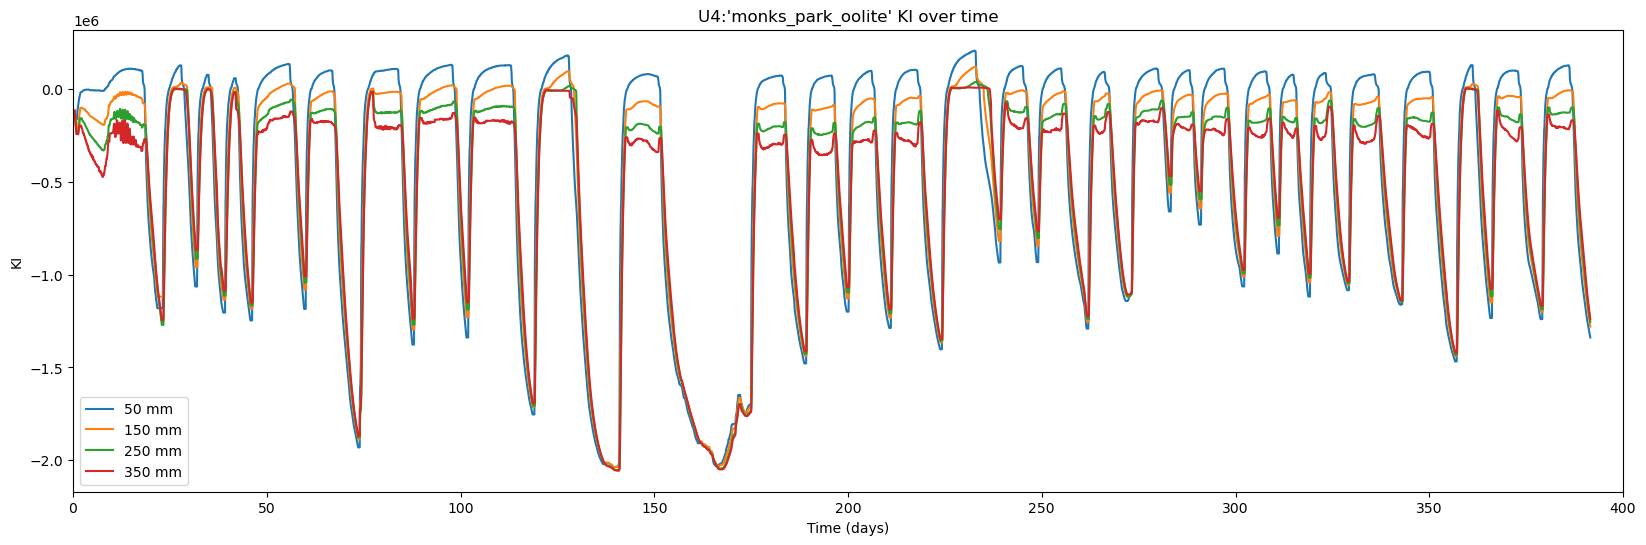

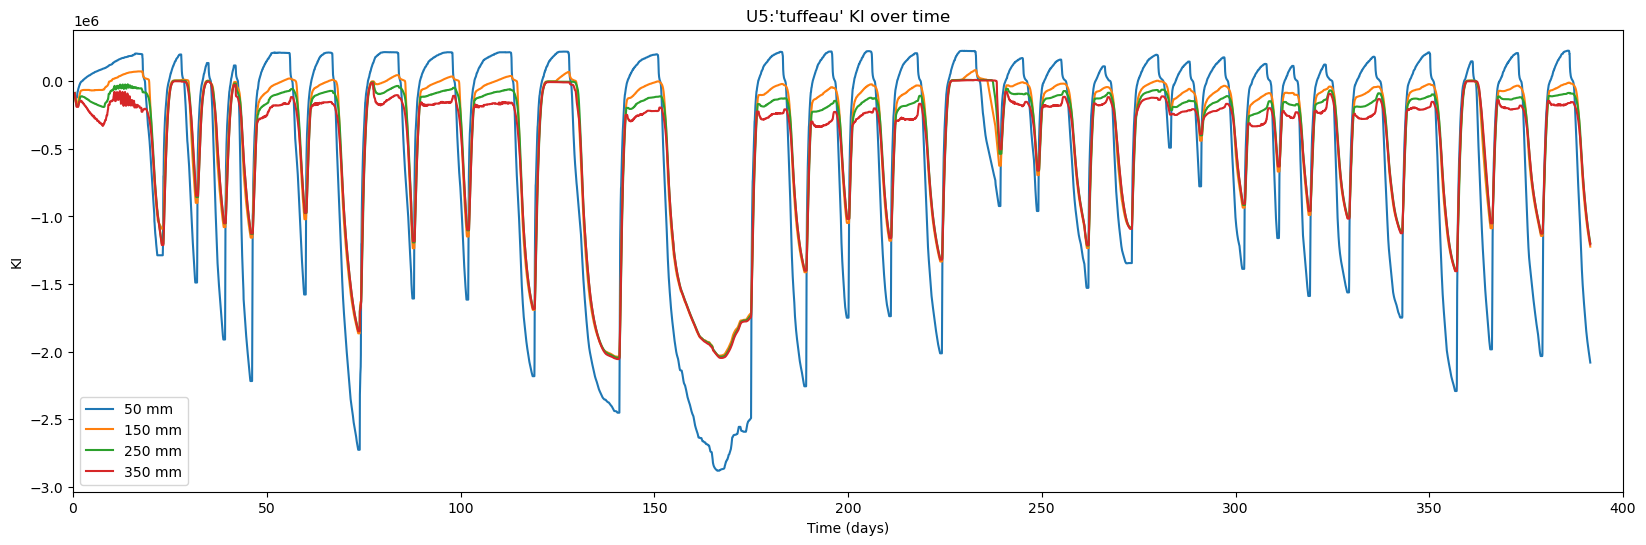

In [50]:
wanted_depths = [50, 150, 250, 350]

for name, data, KI in [('B1',B1dat,sKI_B1), ('B2',B2dat,sKI_B2), ('B3',B3dat,sKI_B3), ('B4',B4dat,sKI_B4), \
                   ('U1',U1dat,sKI_U1), ('U2',U2dat,sKI_U2), ('U3',U3dat,sKI_U3), ('U4',U4dat,sKI_U4), ('U5',U5dat,sKI_U5)]:
    depths, _ = depth_list_from_cols(data)
    KI_df = pd.DataFrame(KI)
    smoothed_data = KI_df.rolling(window=21, center=True).median()
    smoothed_data = smoothed_data.to_numpy()
    plt.figure(figsize=(20, 6))
    for j, depth in enumerate(depths):
        if depth in wanted_depths:
            plt.plot(data['t_d'], smoothed_data[:, j], label=f'{depth} mm')
    #plt.yscale('log')
    plt.xlabel('Time (days)')
    plt.ylabel('KI')
    plt.title(F"{name}:'{block_rock_type[name]}' KI over time")
    plt.xlim(0, 400)
    plt.legend()
    plt.savefig(f'KI_{name}.png', dpi=400, bbox_inches='tight')
    plt.show()

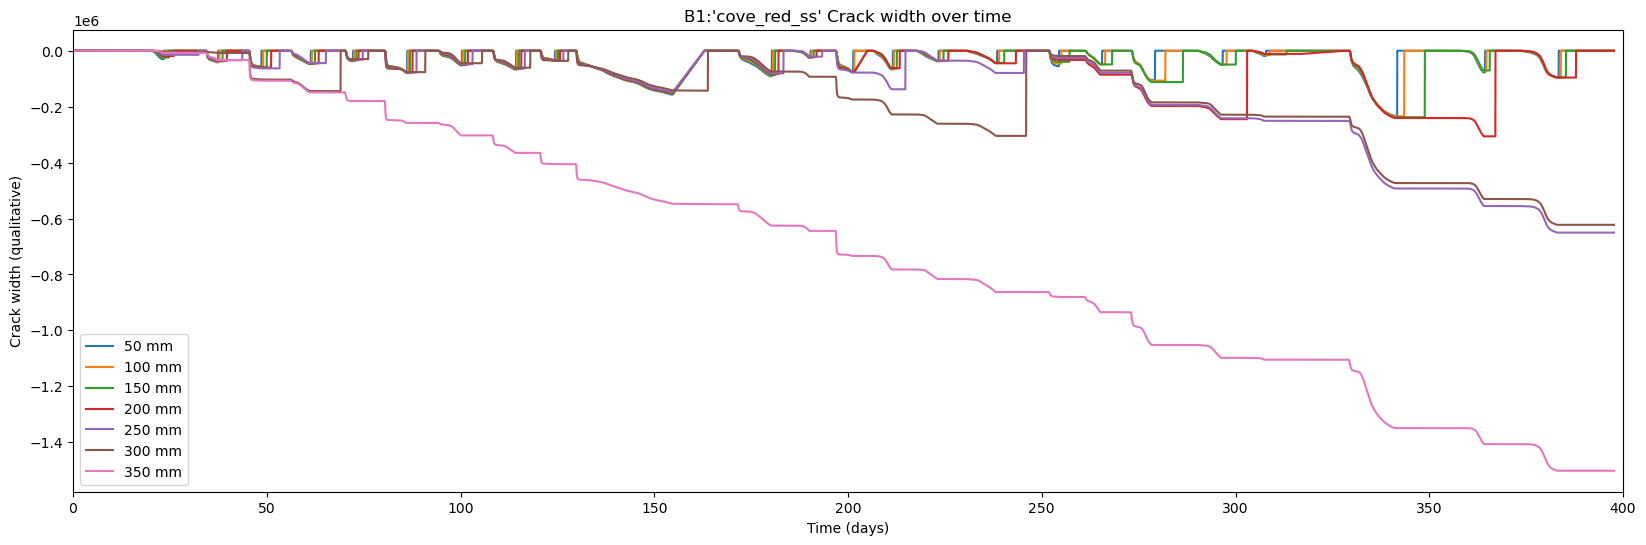

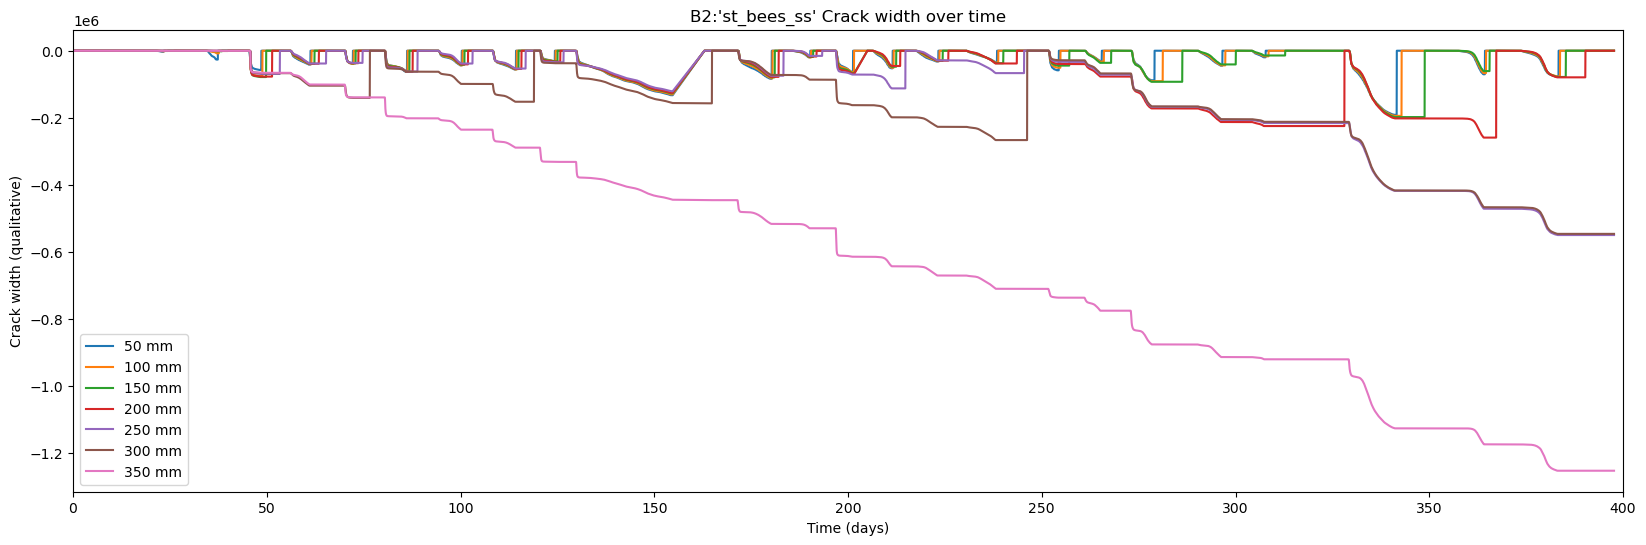

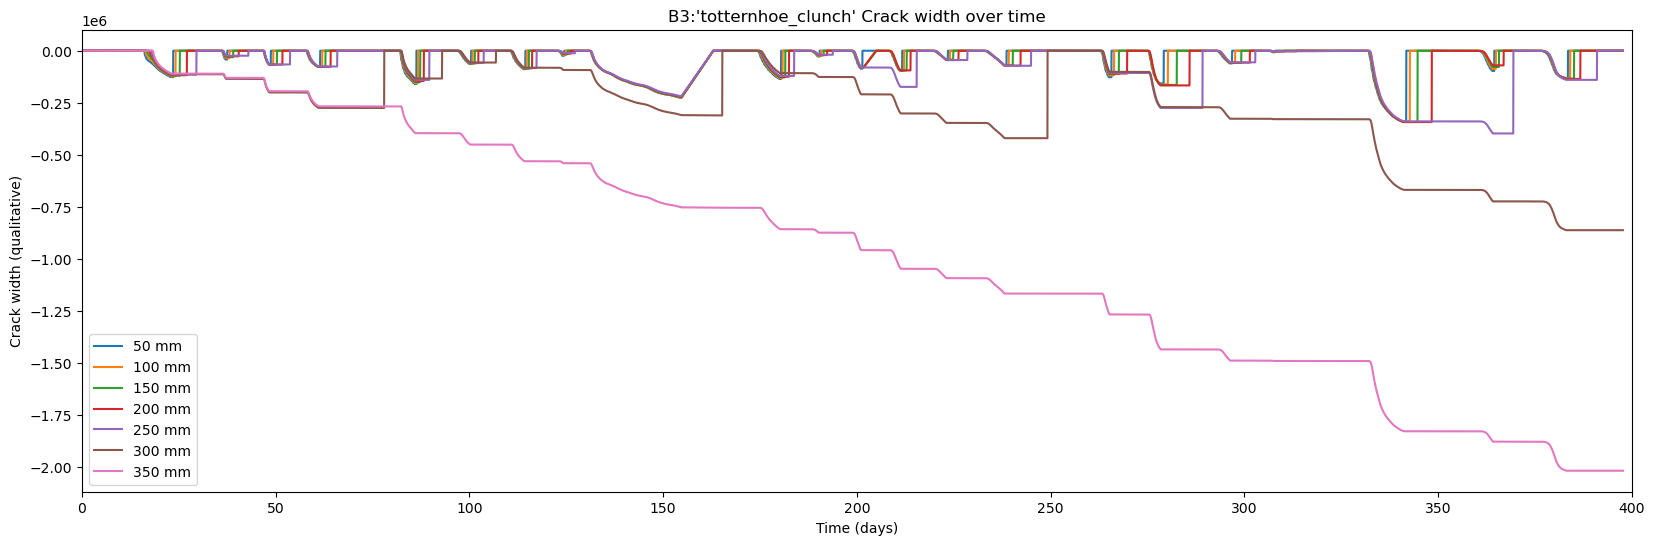

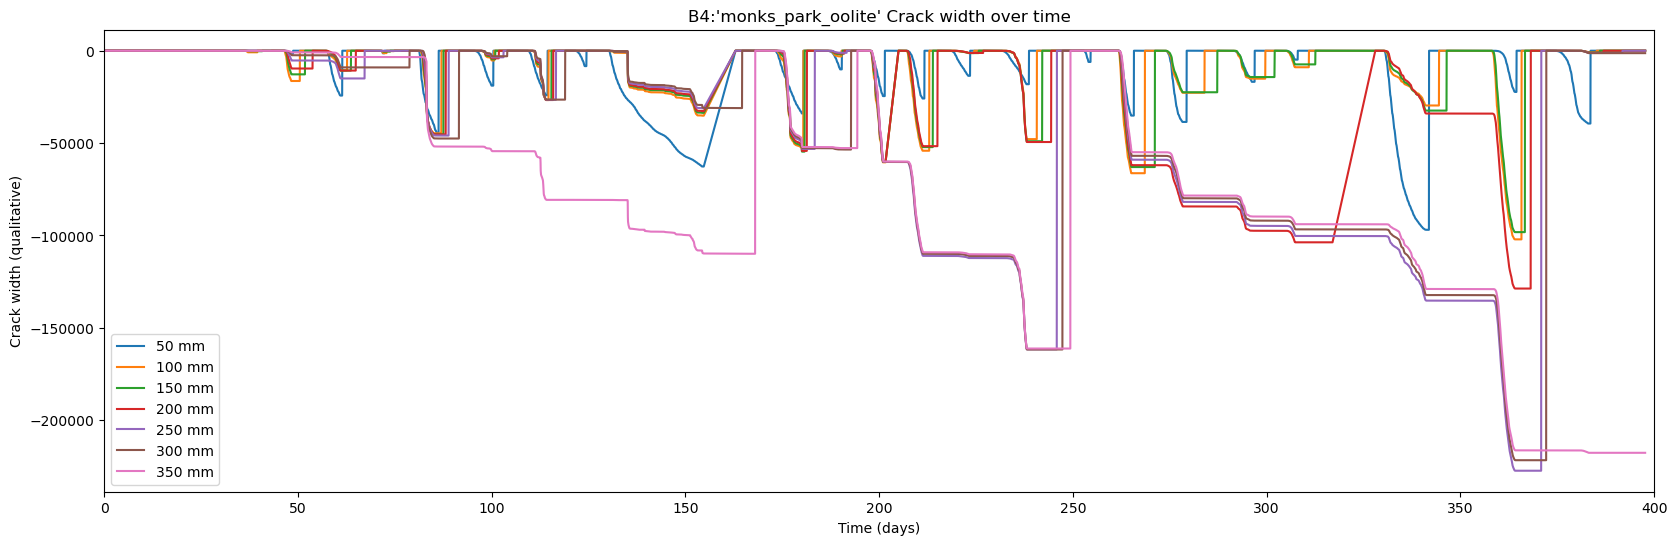

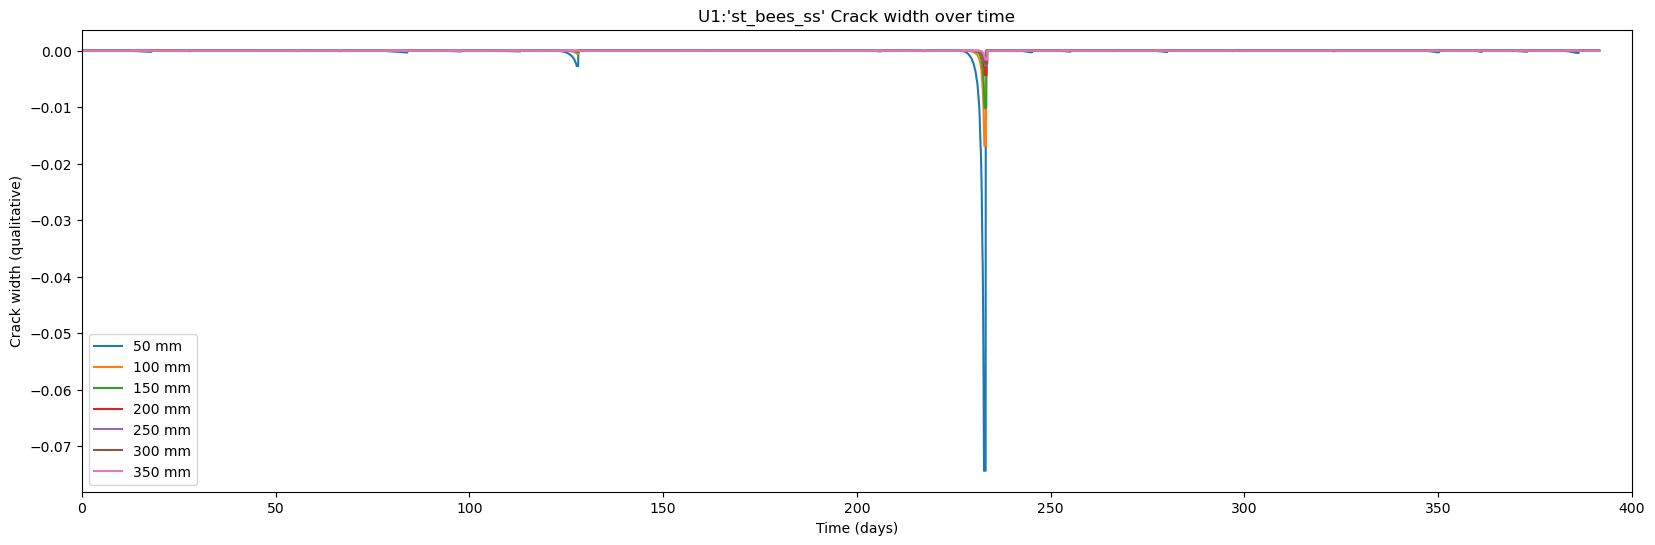

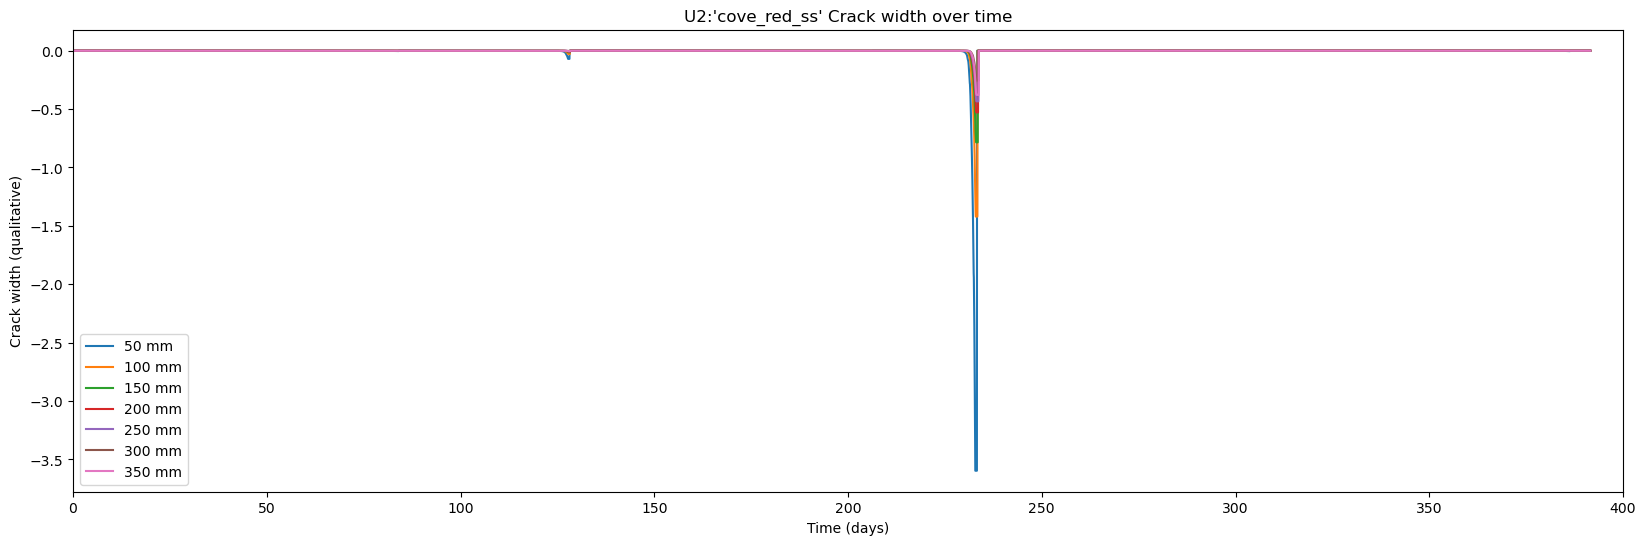

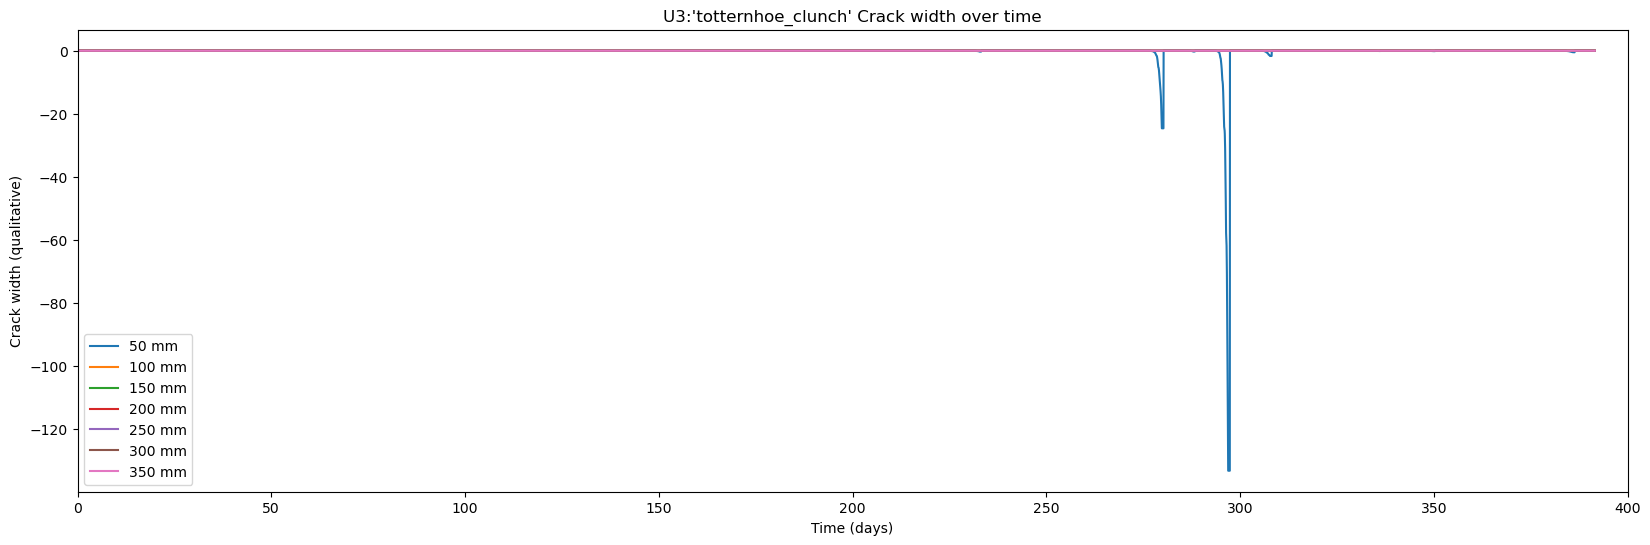

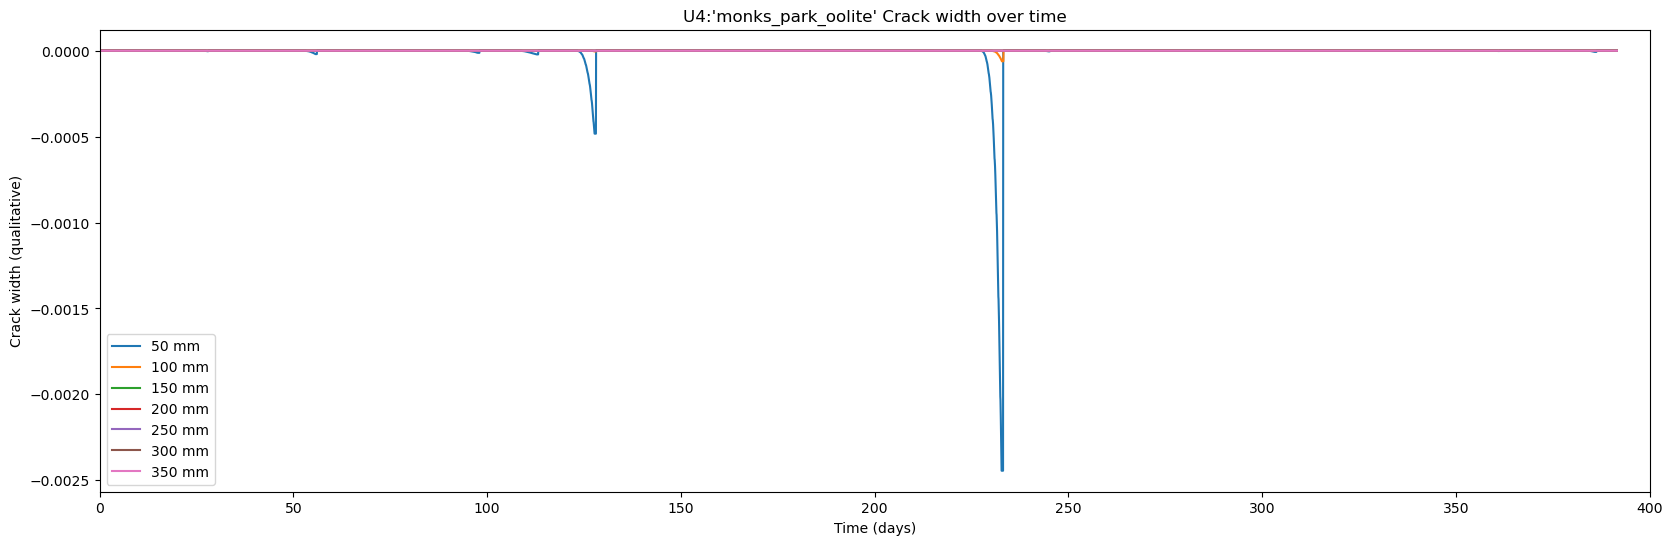

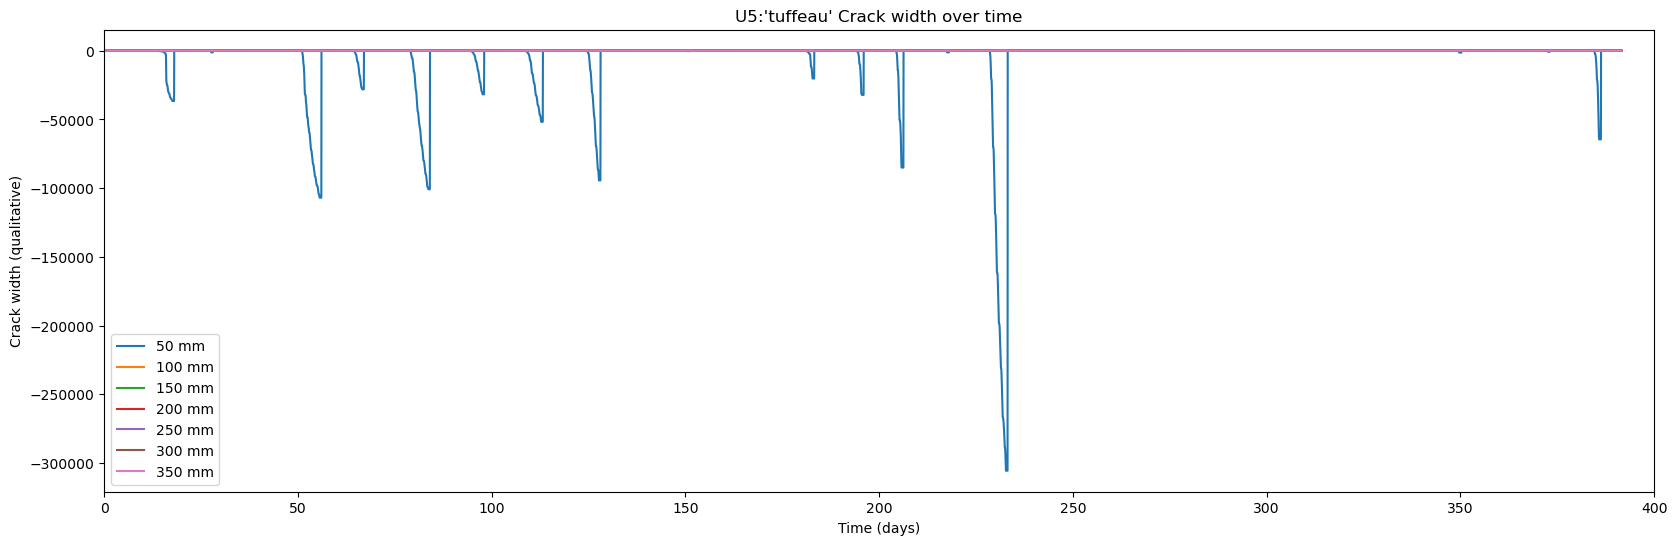

In [51]:
wanted_depths = [50, 100, 150, 200, 250, 300, 350]

for name, data, w in [('B1',B1dat,sw_B1), ('B2',B2dat,sw_B2), ('B3',B3dat,sw_B3), ('B4',B4dat,sw_B4), \
                   ('U1',U1dat,sw_U1), ('U2',U2dat,sw_U2), ('U3',U3dat,sw_U3), ('U4',U4dat,sw_U4), ('U5',U5dat,sw_U5)]:
    depths, _ = depth_list_from_cols(data)
    w_df = pd.DataFrame(w)
    smoothed_data = w_df.rolling(window=21, center=True).median()
    smoothed_data = smoothed_data.to_numpy()
    plt.figure(figsize=(20, 6))
    for j, depth in enumerate(depths):
        if depth in wanted_depths:
            plt.plot(data['t_d'], smoothed_data[:, j], label=f'{depth} mm')
    #plt.yscale('log')
    plt.xlabel('Time (days)')
    plt.ylabel('Crack width (qualitative)')
    #plt.ylim(0, np.max(w))
    plt.xlim(0, 400)
    plt.title(F"{name}:'{block_rock_type[name]}' Crack width over time")
    plt.legend()
    #plt.savefig(f'w_{name}.png', dpi=400, bbox_inches='tight')
    plt.show()

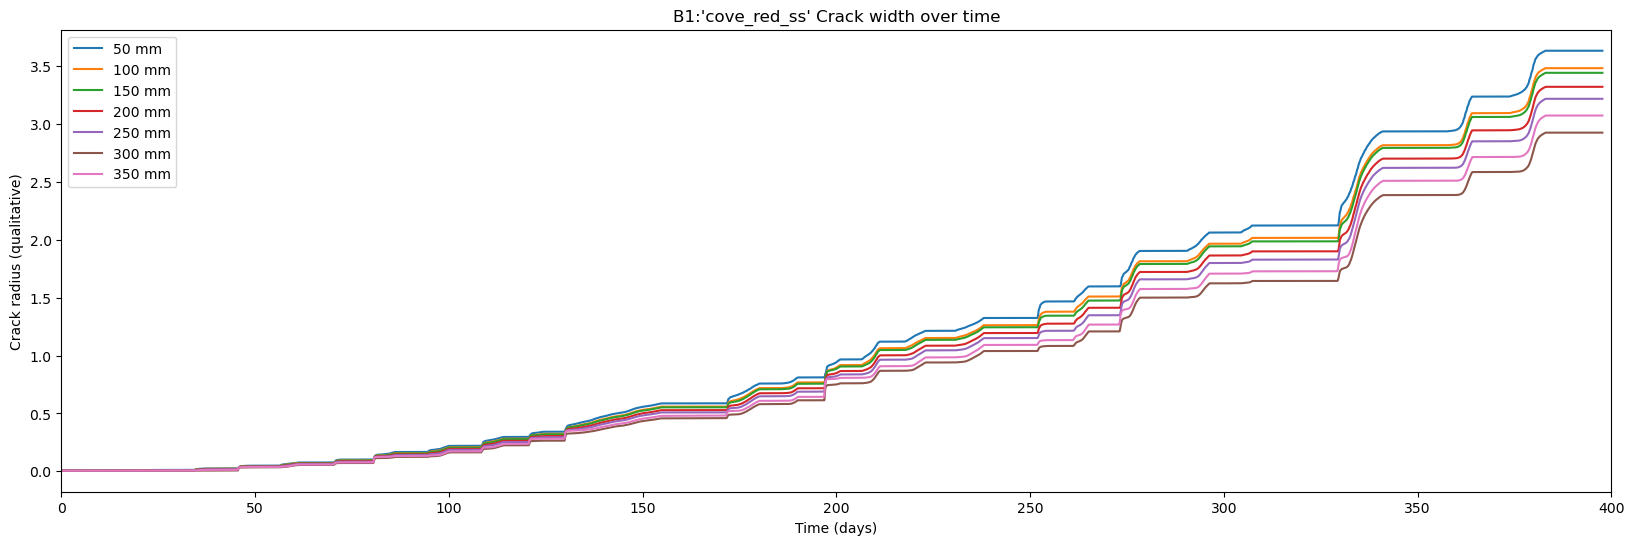

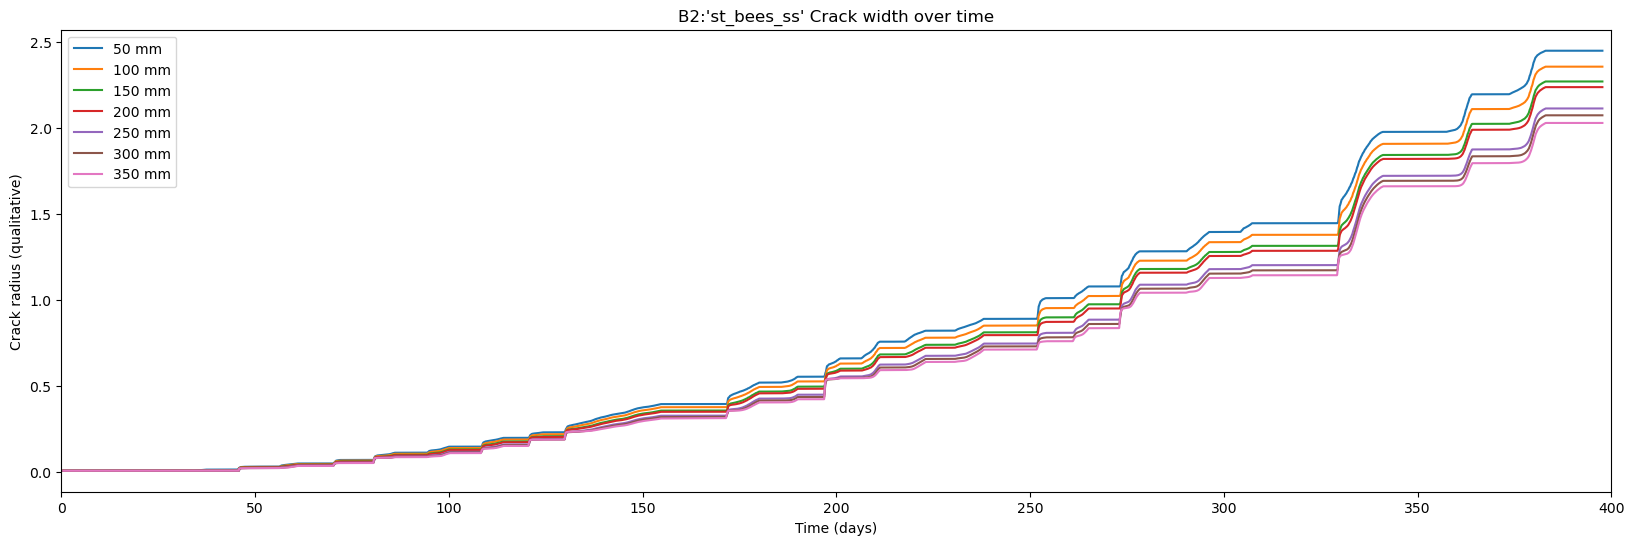

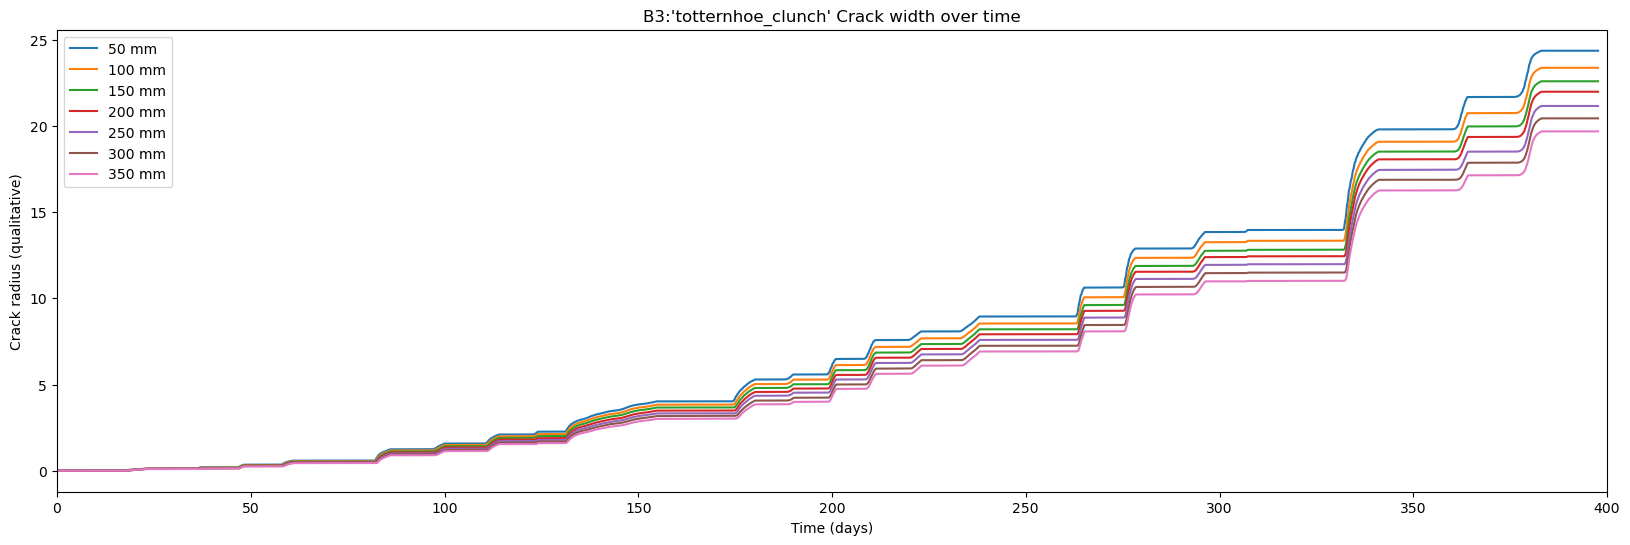

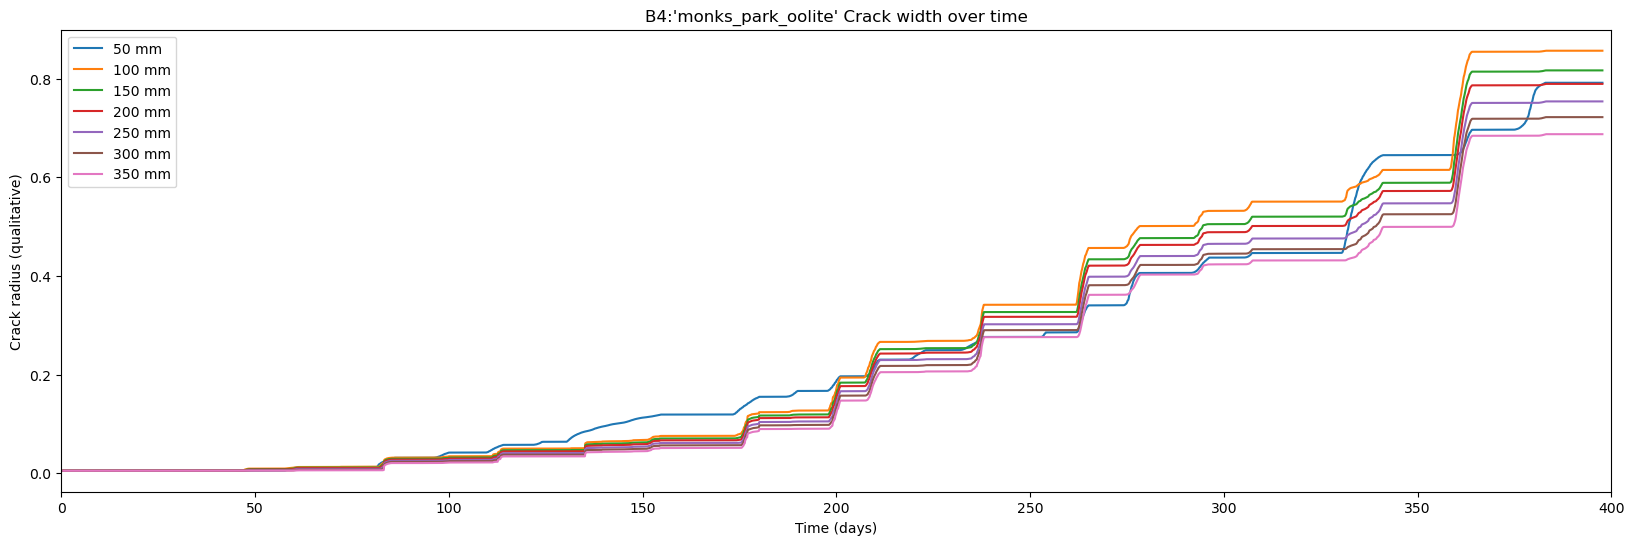

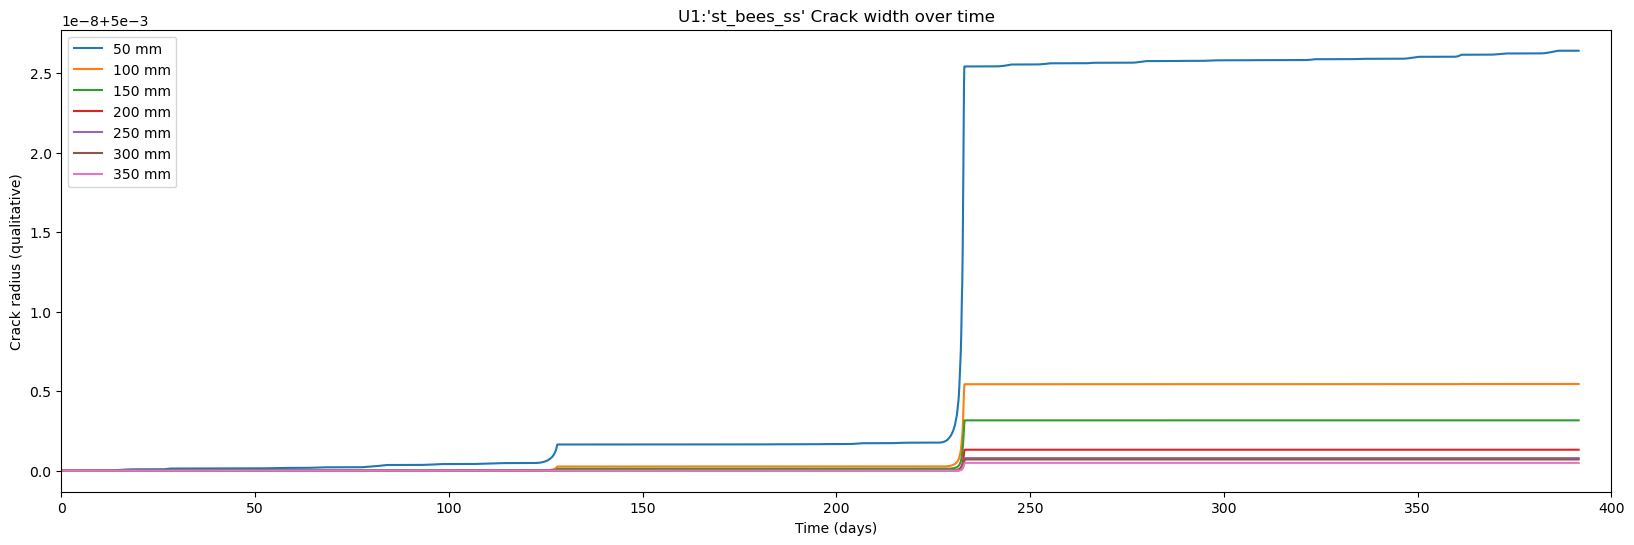

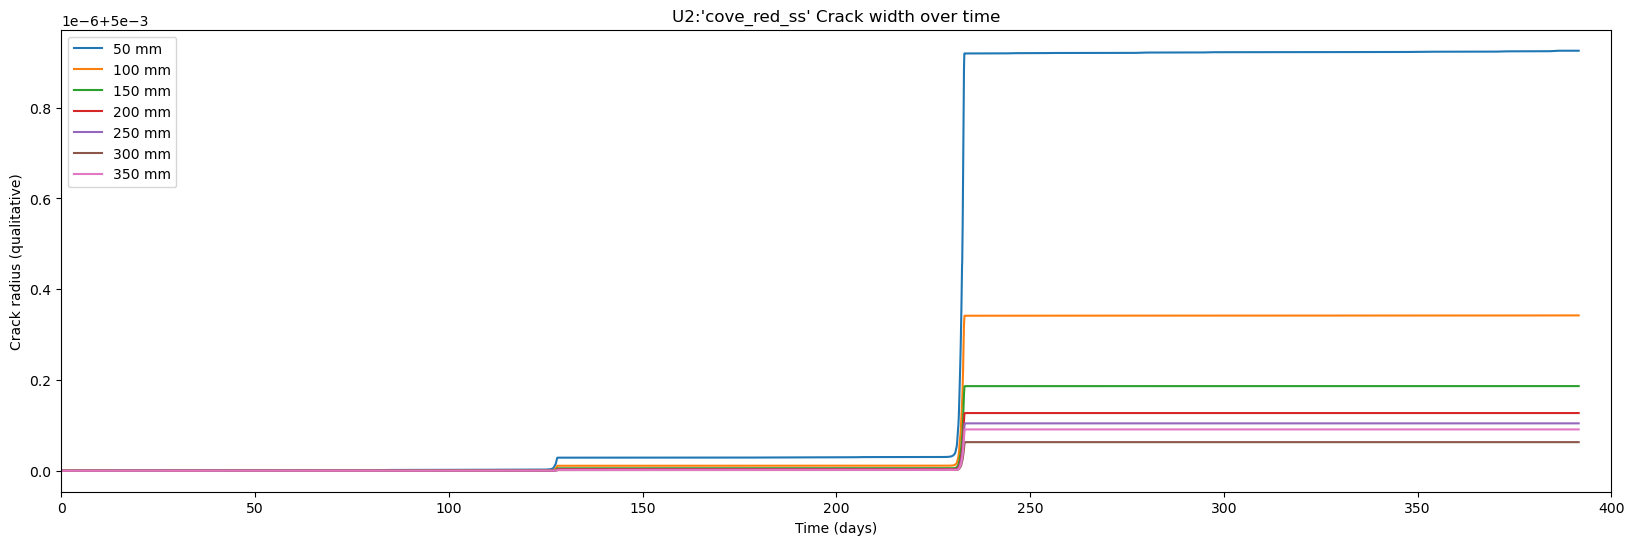

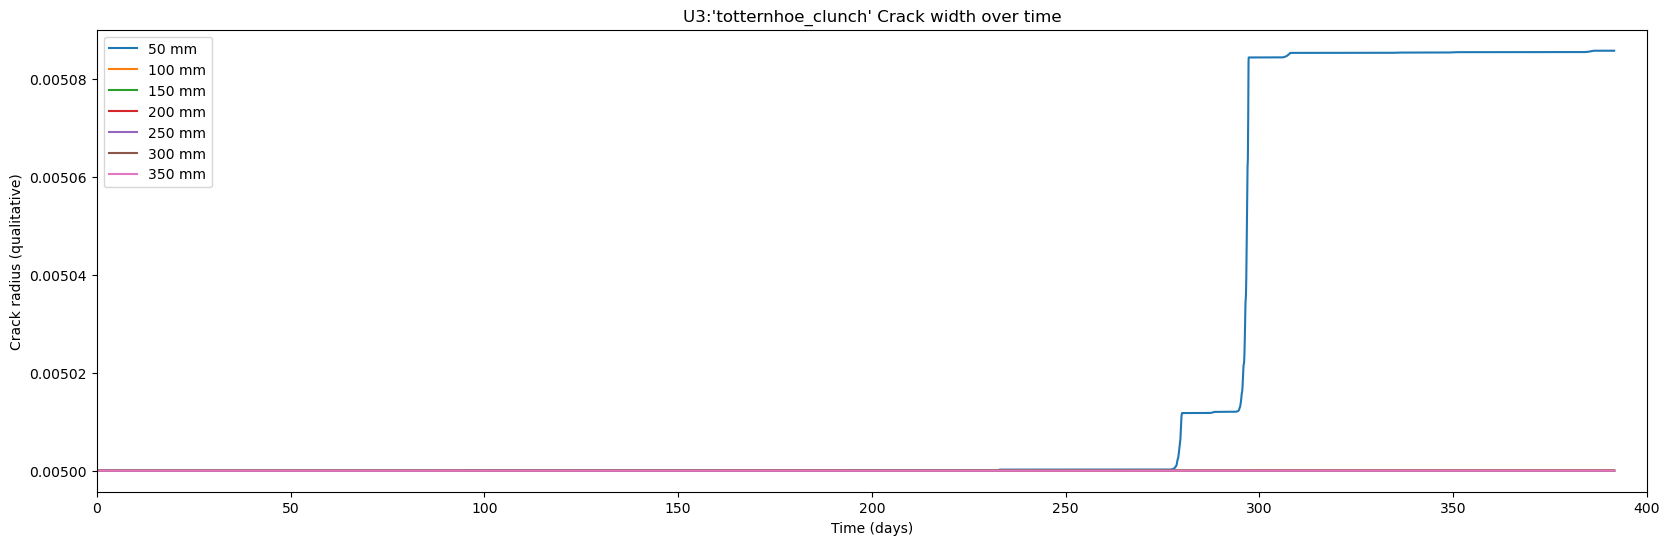

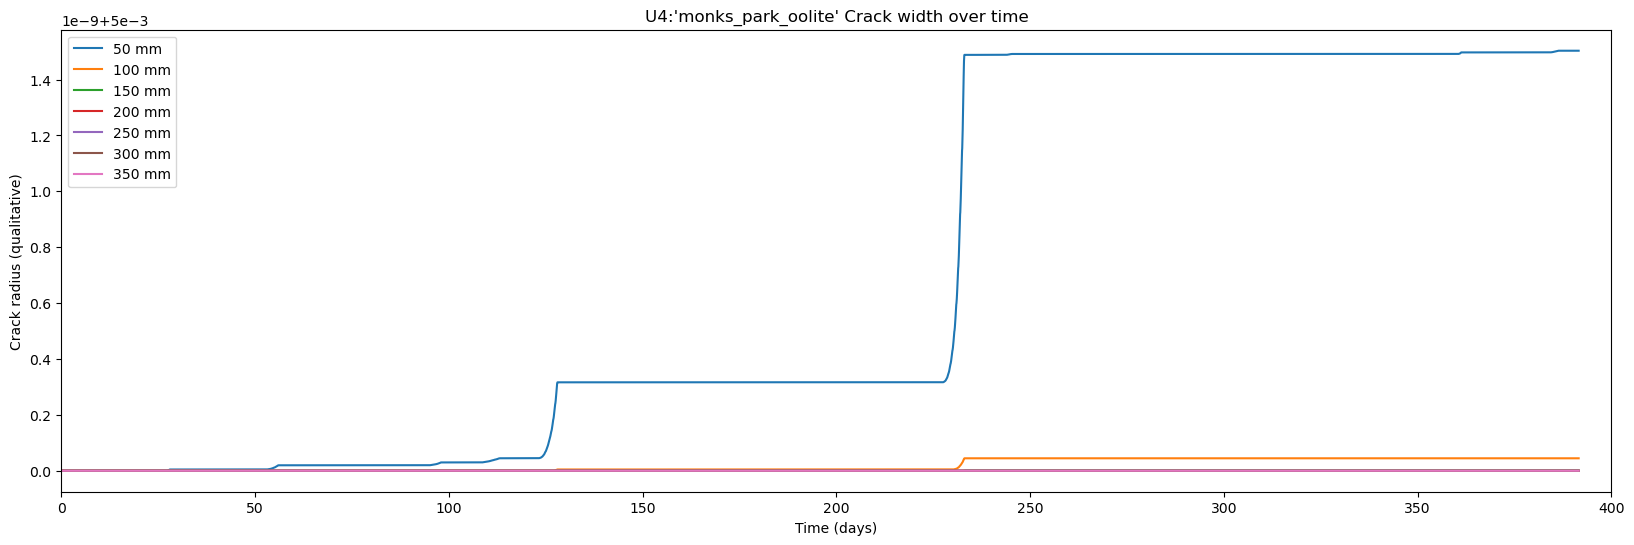

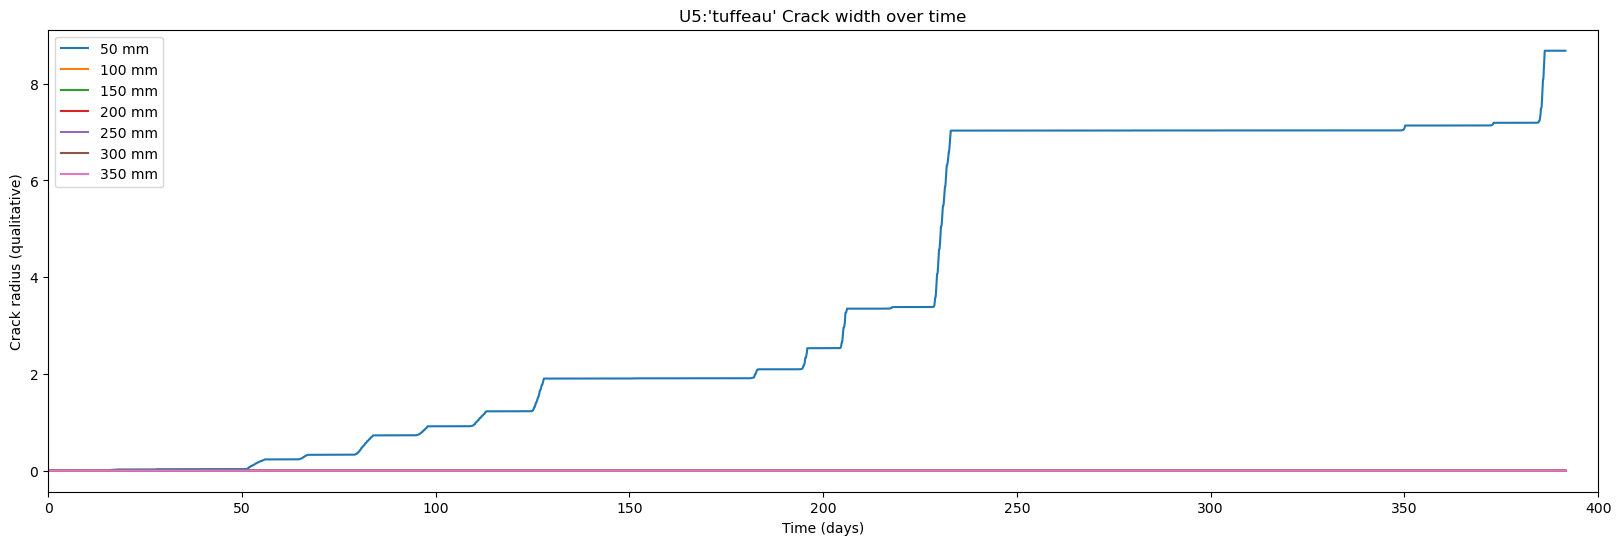

In [52]:
wanted_depths = [50, 100, 150, 200, 250, 300, 350]

for name, data, c in [('B1',B1dat,sc_B1), ('B2',B2dat,sc_B2), ('B3',B3dat,sc_B3), ('B4',B4dat,sc_B4), \
                   ('U1',U1dat,sc_U1), ('U2',U2dat,sc_U2), ('U3',U3dat,sc_U3), ('U4',U4dat,sc_U4), ('U5',U5dat,sc_U5)]:
    depths, _ = depth_list_from_cols(data)
    c_df = pd.DataFrame(c)
    smoothed_data = c_df.rolling(window=21, center=True).median()
    smoothed_data = smoothed_data.to_numpy()
    plt.figure(figsize=(20, 6))
    for j, depth in enumerate(depths):
        if depth in wanted_depths:  
            plt.plot(data['t_d'], smoothed_data[:, j], label=f'{depth} mm')
    plt.xlabel('Time (days)')
    plt.ylabel('Crack radius (qualitative)')
    plt.xlim(0, 400)
    plt.title(F"{name}:'{block_rock_type[name]}' Crack width over time")
    plt.legend()
    plt.savefig(f'c_time_{name}.png', dpi=400, bbox_inches='tight')
    plt.show()

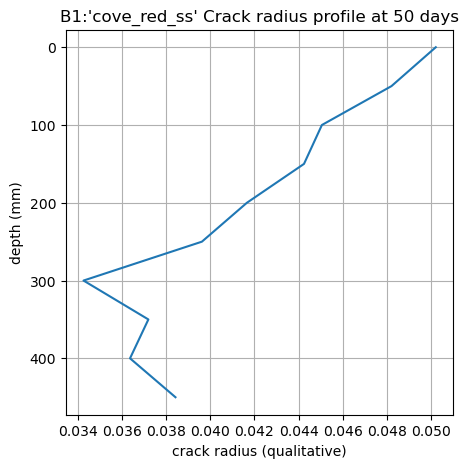

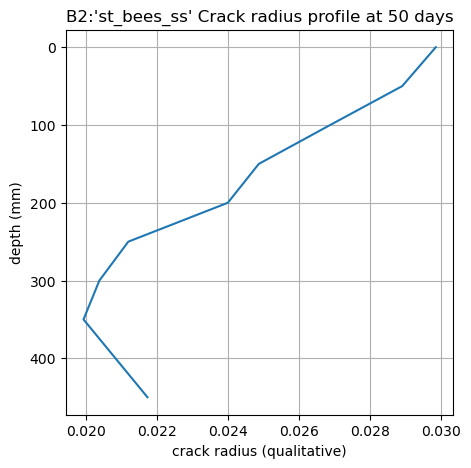

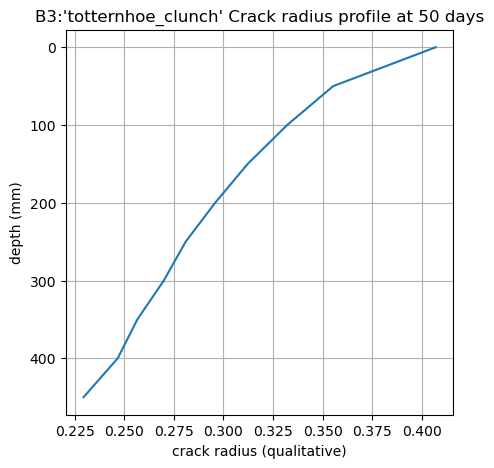

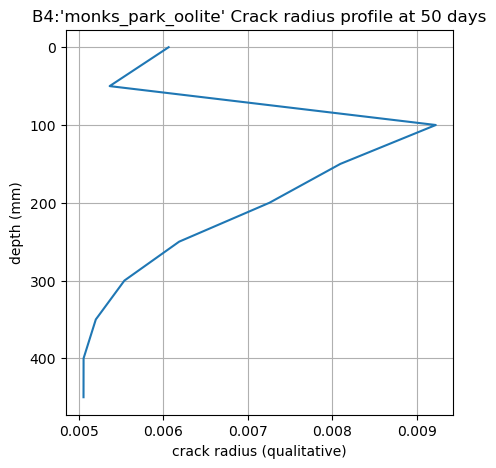

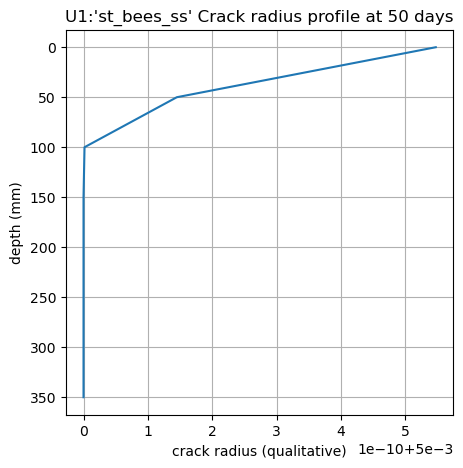

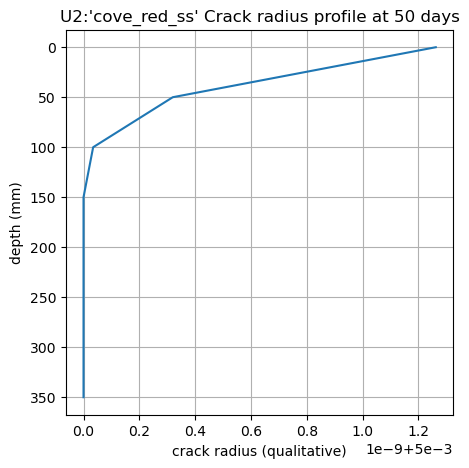

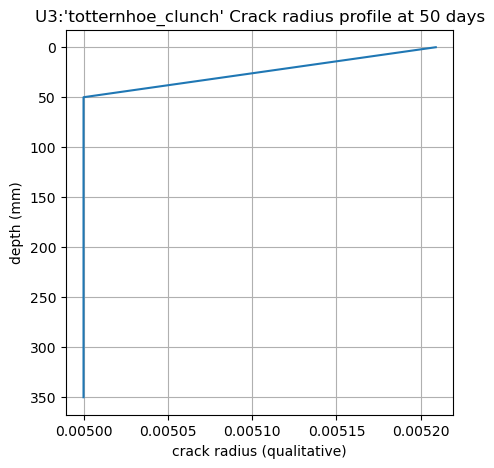

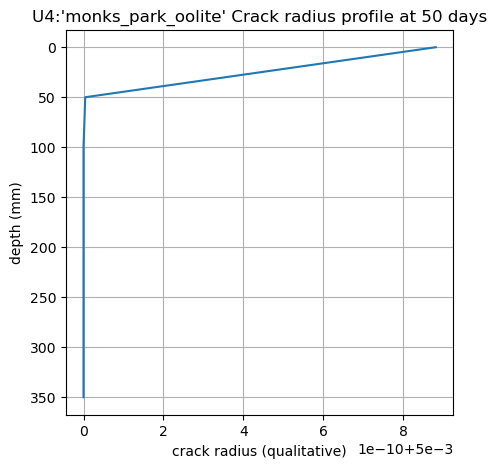

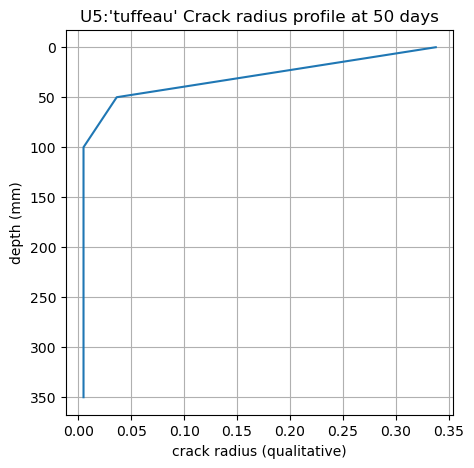

In [53]:
for name, data, c in [('B1',B1dat,sc_B1), ('B2',B2dat,sc_B2), ('B3',B3dat,sc_B3), ('B4',B4dat,sc_B4), \
                   ('U1',U1dat,sc_U1), ('U2',U2dat,sc_U2), ('U3',U3dat,sc_U3), ('U4',U4dat,sc_U4), ('U5',U5dat,sc_U5)]:
    depths, _ = depth_list_from_cols(data)
    lookup_time = 50
    #time_index = data['t_d'].index(min(data['t_d'], key=lambda x:abs(x-lookup_time)))
    time_index = bisect_left(data['t_d'], lookup_time)
    c_df = pd.DataFrame(c)
    c_at_time = c_df.iloc[time_index, :]
    plt.figure(figsize=(5, 5))  
    plt.plot(c_at_time, depths)
    plt.xlabel('crack radius (qualitative)')
    plt.gca().invert_yaxis()
    plt.ylabel('depth (mm)')
    plt.title(F"{name}:'{block_rock_type[name]}' Crack radius profile at 50 days")
    plt.grid(True)
    #plt.legend()
    plt.savefig(f'c_profile_50d_{name}.png', dpi=400, bbox_inches='tight')
    plt.show()

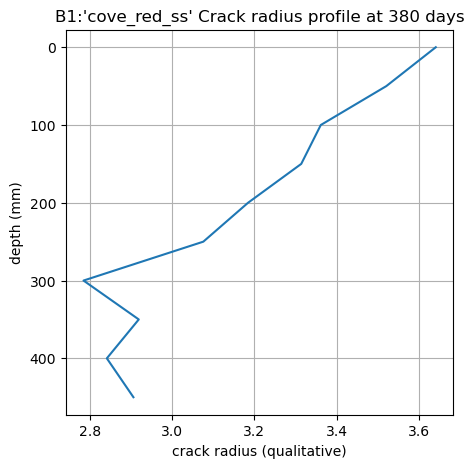

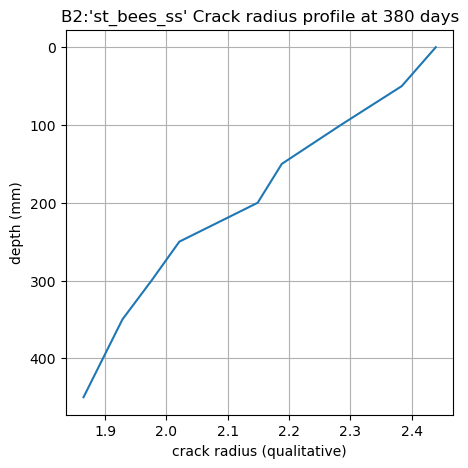

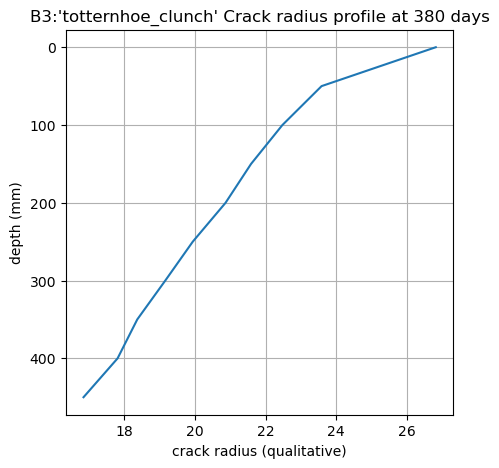

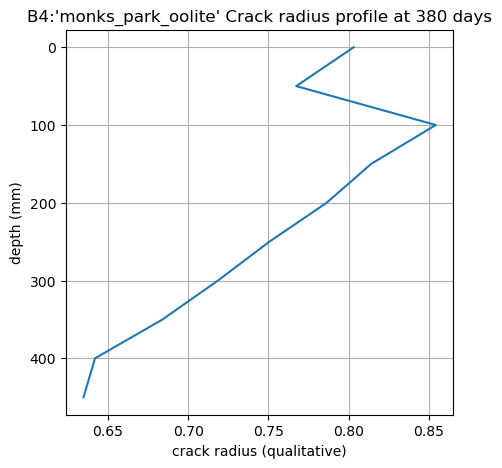

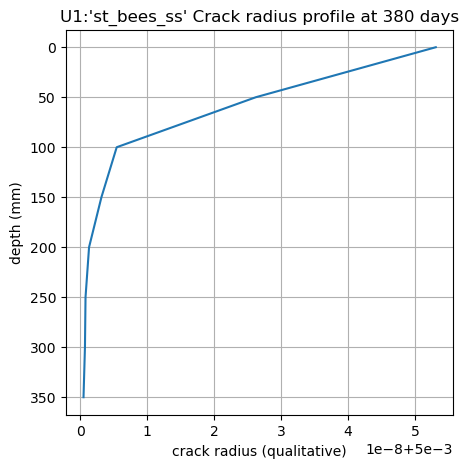

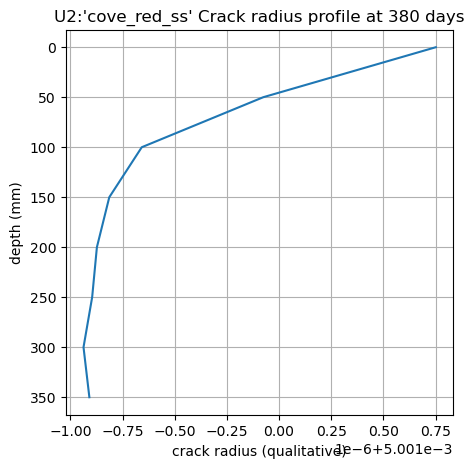

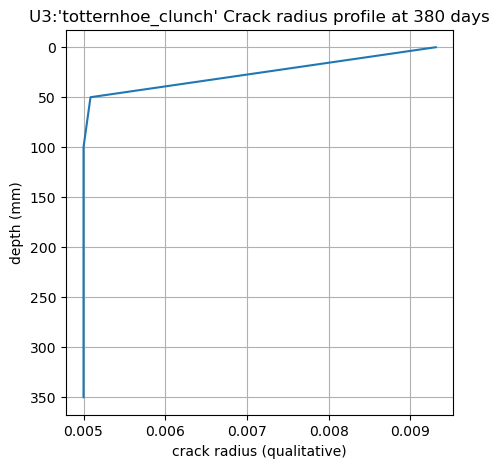

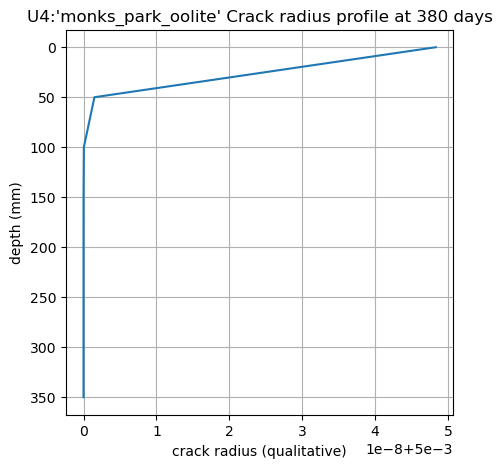

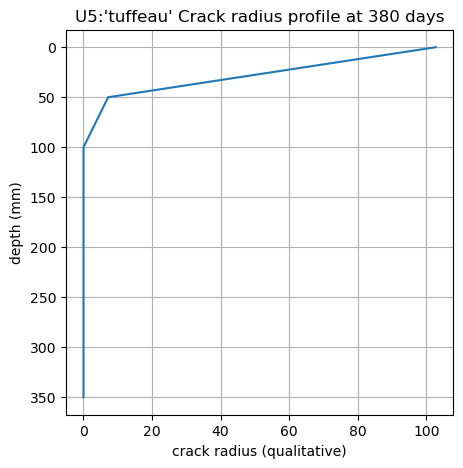

In [54]:
for name, data, c in [('B1',B1dat,sc_B1), ('B2',B2dat,sc_B2), ('B3',B3dat,sc_B3), ('B4',B4dat,sc_B4), \
                   ('U1',U1dat,sc_U1), ('U2',U2dat,sc_U2), ('U3',U3dat,sc_U3), ('U4',U4dat,sc_U4), ('U5',U5dat,sc_U5)]:
    depths, _ = depth_list_from_cols(data)
    lookup_time = 380
    #time_index = data['t_d'].index(min(data['t_d'], key=lambda x:abs(x-lookup_time)))
    time_index = bisect_left(data['t_d'], lookup_time)
    c_df = pd.DataFrame(c)
    c_at_time = c_df.iloc[time_index, :]
    plt.figure(figsize=(5, 5))  
    plt.plot(c_at_time, depths)
    plt.xlabel('crack radius (qualitative)')
    plt.gca().invert_yaxis()
    plt.ylabel('depth (mm)')
    plt.title(F"{name}:'{block_rock_type[name]}' Crack radius profile at {lookup_time} days")
    plt.grid(True)
    #plt.legend()
    plt.savefig(f'c_profile_380d_{name}.png', dpi=400, bbox_inches='tight')
    plt.show()

In [55]:
from IPython.display import Audio
sound_file = './beep.mp3'
Audio(sound_file, autoplay=True)